In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path

# Set the folder where the data files are stored
DATA_DIR = Path(r"D:\data")

# Define the two data file paths
housebuilding_file = DATA_DIR / "indicatorsofukhousebuilding.xlsx"
stock_file = DATA_DIR / "LiveTable104.ods"

# Print the file paths to check whether they are correct
print(housebuilding_file)
print(stock_file)

# Check whether the files exist in the folder
print("Housebuilding file exists:", housebuilding_file.exists())
print("Stock file exists:", stock_file.exists())

D:\data\indicatorsofukhousebuilding.xlsx
D:\data\LiveTable104.ods
Housebuilding file exists: True
Stock file exists: True


In [4]:
# Load the Excel file and display all sheet names
xls = pd.ExcelFile(housebuilding_file)
xls.sheet_names

['Contents',
 'Metadata',
 'Source Information',
 'Terms and Conditions',
 '1a',
 '1b',
 '1c',
 '1d',
 '1e',
 '1f',
 '2a',
 '2b',
 '2c',
 '2d',
 '2e',
 '3a',
 '3b',
 '3c',
 '3d',
 '3e']

In [5]:
# Read sheet 1b, which contains England quarterly housebuilding data
raw = pd.read_excel(
    housebuilding_file,
    sheet_name="1b",
    header=5
)

# Display the first few rows
raw.head()


,Revised,Period,Started - All Dwellings,Started - Private Enterprise,Started - Housing Associations,Started - Local Authorities,Completed - All Dwellings,Completed - Private Enterprise,Completed - Housing Associations,Completed - Local Authorities
0,,Jan - Mar 1978,45700,25880,4460,15360,57360,30230,4840,22290
1,,Apr - Jun 1978,69520,39760,4810,24950,61450,32930,4980,23540
2,,Jul - Sep 1978,59340,34490,4590,20270,59160,30620,5260,23280
3,,Oct - Dec 1978,52130,33450,4100,14580,63340,33660,5480,24200
4,,Jan - Mar 1979,31960,19060,3220,9680,43380,24810,4160,14410


In [6]:
df = raw.rename(columns={
    "Period": "period",
    "Started - All Dwellings": "starts_all",
    "Completed - All Dwellings": "completions_all",
    "Started - Private Enterprise": "starts_private",
    "Completed - Private Enterprise": "completions_private"
})

df = df[[
    "period",
    "starts_all",
    "completions_all",
    "starts_private",
    "completions_private"
]].copy()

for col in [
    "starts_all",
    "completions_all",
    "starts_private",
    "completions_private"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [7]:
def parse_quarter(x):
    x = str(x)

    if len(x) < 4:
        return pd.NaT

    try:
        year = int(x[-4:])
    except:
        return pd.NaT

    if x.startswith("Jan - Mar"):
        q = 1
    elif x.startswith("Apr - Jun"):
        q = 2
    elif x.startswith("Jul - Sep"):
        q = 3
    elif x.startswith("Oct - Dec"):
        q = 4
    else:
        return pd.NaT

    return pd.Period(
        year=year,
        quarter=q,
        freq="Q"
    )


df["quarter"] = df["period"].apply(parse_quarter)

df = df.dropna(subset=["quarter"])
df = df.set_index("quarter").sort_index()

print(df.head())
print(df.tail())
print(df.index.min(), df.index.max())

                 period  starts_all  completions_all  starts_private  \
quarter                                                                
1978Q1   Jan - Mar 1978       45700            57360           25880   
1978Q2   Apr - Jun 1978       69520            61450           39760   
1978Q3   Jul - Sep 1978       59340            59160           34490   
1978Q4   Oct - Dec 1978       52130            63340           33450   
1979Q1   Jan - Mar 1979       31960            43380           19060   

         completions_private  
quarter                       
1978Q1                 30230  
1978Q2                 32930  
1978Q3                 30620  
1978Q4                 33660  
1979Q1                 24810  
                 period  starts_all  completions_all  starts_private  \
quarter                                                                
2024Q4   Oct - Dec 2024       25570            40850           18780   
2025Q1   Jan - Mar 2025       29220            32560          

In [8]:
print(df.columns)

Index(['period', 'starts_all', 'completions_all', 'starts_private',
       'completions_private'],
      dtype='object')


In [9]:
# Check the start and end quarters of the dataset
print(df.index.min())
print(df.index.max())

# Display the last few rows
df.tail()

1978Q1
2025Q4


,period,starts_all,completions_all,starts_private,completions_private
quarter,,,,,
2024Q4,Oct - Dec 2024,25570,40850,18780,29910
2025Q1,Jan - Mar 2025,29220,32560,21960,23690
2025Q2,Apr - Jun 2025,31800,37000,23360,27900
2025Q3,Jul - Sep 2025,31740,30920,22880,23120
2025Q4,Oct - Dec 2025,32100,41570,25380,29700


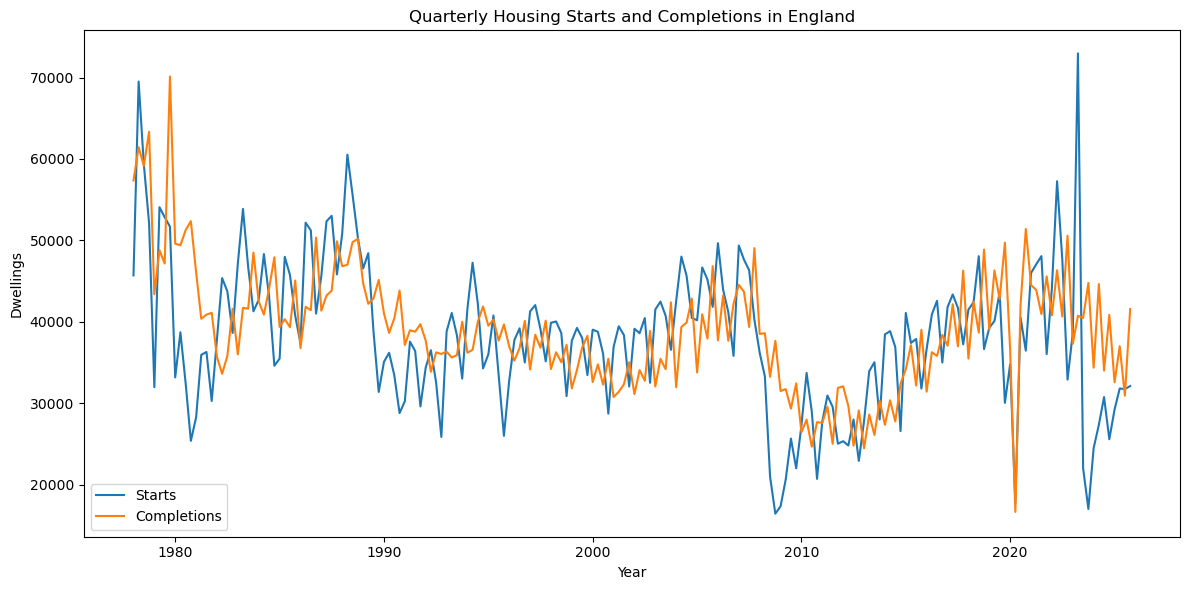

In [10]:
# Convert the quarterly index to timestamp format for plotting
plot_df = df.copy()
plot_df["date"] = plot_df.index.to_timestamp()

# Plot starts and completions over time
plt.figure(figsize=(12, 6))
plt.plot(plot_df["date"], plot_df["starts_all"], label="Starts")
plt.plot(plot_df["date"], plot_df["completions_all"], label="Completions")
plt.title("Quarterly Housing Starts and Completions in England")
plt.xlabel("Year")
plt.ylabel("Dwellings")
plt.legend()
plt.tight_layout()
plt.show()

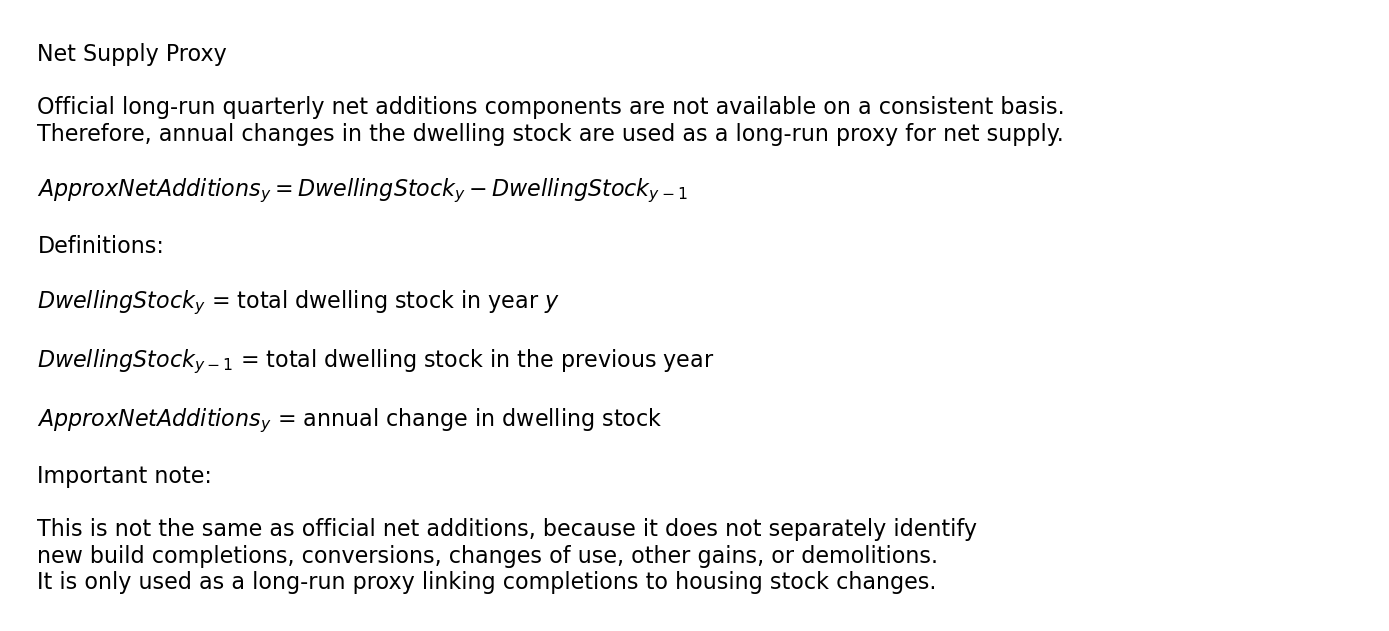

In [11]:
import matplotlib.pyplot as plt

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = DATA_DIR / "outputs"
    OUTPUT_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.axis("off")

formula_text = r"""
Net Supply Proxy

Official long-run quarterly net additions components are not available on a consistent basis.
Therefore, annual changes in the dwelling stock are used as a long-run proxy for net supply.

$ApproxNetAdditions_y = DwellingStock_y - DwellingStock_{y-1}$

Definitions:

$DwellingStock_y$ = total dwelling stock in year $y$

$DwellingStock_{y-1}$ = total dwelling stock in the previous year

$ApproxNetAdditions_y$ = annual change in dwelling stock

Important note:

This is not the same as official net additions, because it does not separately identify
new build completions, conversions, changes of use, other gains, or demolitions.
It is only used as a long-run proxy linking completions to housing stock changes.
"""

ax.text(0.02, 0.98, formula_text, fontsize=16, va="top", ha="left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "formula_2_net_supply_proxy.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Load LiveTable104 dwelling stock data
stock_raw = pd.read_excel(
    stock_file,
    sheet_name="LT_104",
    header=4,
    engine="odf"
)

stock_raw.head()

,Date,Year,Owner occupied,Rented privately or with a job or business,Rented from private registered providers,Rented from local authorities,Other public sector dwellings,All dwellings,Notes
0,1 April,1801,[x],[x],[x],[x],[x],1512000,NaN
1,1 April,1811,[x],[x],[x],[x],[x],1714000,NaN
2,1 April,1821,[x],[x],[x],[x],[x],2004000,NaN
3,1 April,1831,[x],[x],[x],[x],[x],2420000,NaN
4,1 April,1841,[x],[x],[x],[x],[x],2890000,NaN


In [14]:
# Keep year and all dwellings columns
stock = stock_raw[["Year", "All dwellings"]].copy()

# Rename columns
stock = stock.rename(columns={
    "Year": "year",
    "All dwellings": "dwelling_stock"
})

# Convert columns to numeric format
stock["year"] = pd.to_numeric(stock["year"], errors="coerce")
stock["dwelling_stock"] = pd.to_numeric(stock["dwelling_stock"], errors="coerce")

# Keep observations from 1978 onwards
stock = stock.dropna(subset=["year", "dwelling_stock"])
stock = stock[stock["year"] >= 1978].copy()

# Calculate approximate net additions as annual change in dwelling stock
stock["approx_net_additions"] = stock["dwelling_stock"].diff()

stock.head()

,year,dwelling_stock,approx_net_additions
27,1978,17603000.0,NaN
28,1979,17782000.0,179000.0
29,1980,17864000.0,82000.0
30,1981,17912000.0,48000.0
31,1981,18018000.0,106000.0


In [15]:
stock.tail()

,year,dwelling_stock,approx_net_additions
71,2021,24927588.0,217754.0
72,2022,25162050.0,234462.0
73,2023,25396342.0,234292.0
74,2024,25617751.0,221409.0
75,2025,25826351.0,208600.0


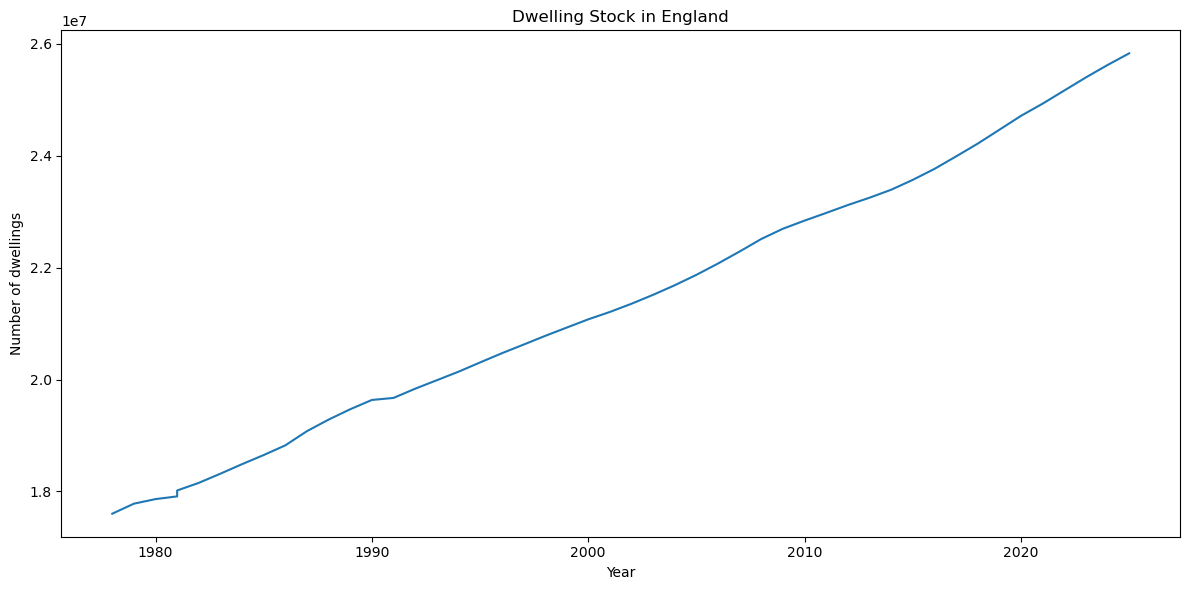

In [16]:
# Plot dwelling stock over time
plt.figure(figsize=(12, 6))
plt.plot(stock["year"], stock["dwelling_stock"])
plt.title("Dwelling Stock in England")
plt.xlabel("Year")
plt.ylabel("Number of dwellings")
plt.tight_layout()
plt.show()

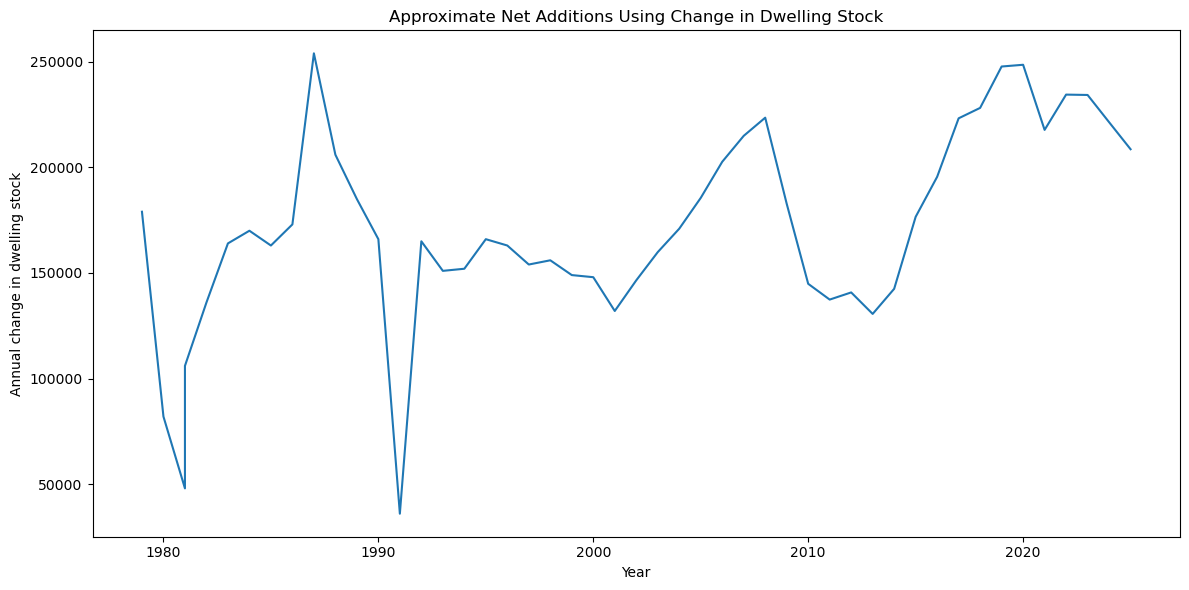

In [17]:
# Plot approximate net additions using annual change in dwelling stock
plt.figure(figsize=(12, 6))
plt.plot(stock["year"], stock["approx_net_additions"])
plt.title("Approximate Net Additions Using Change in Dwelling Stock")
plt.xlabel("Year")
plt.ylabel("Annual change in dwelling stock")
plt.tight_layout()
plt.show()

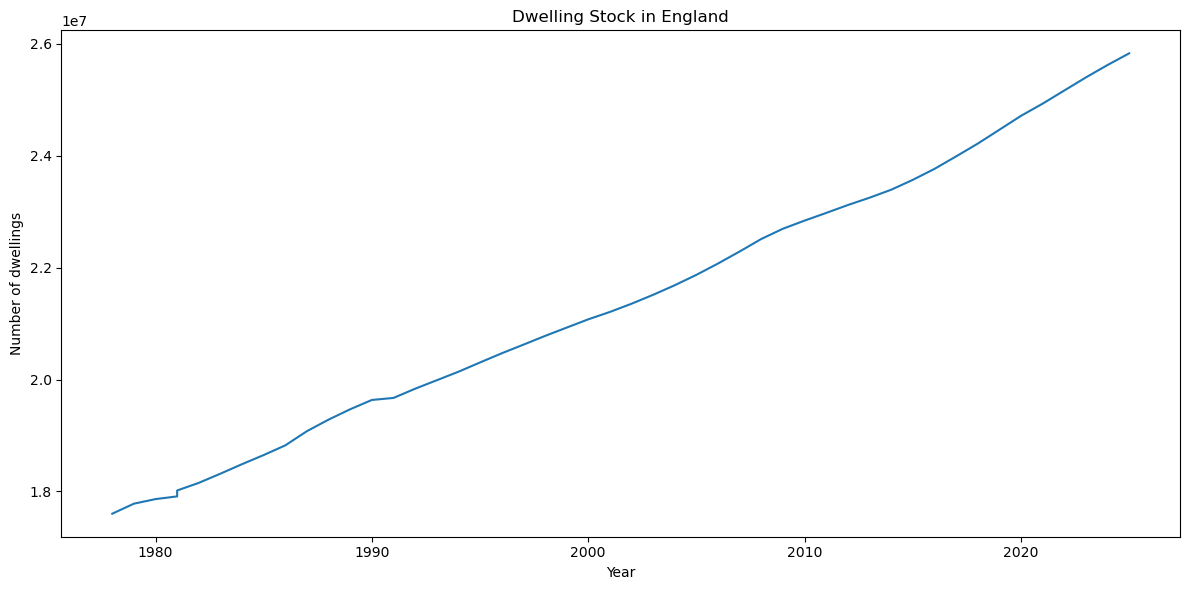

In [18]:
# Save dwelling stock figure
plt.figure(figsize=(12, 6))
plt.plot(stock["year"], stock["dwelling_stock"])
plt.title("Dwelling Stock in England")
plt.xlabel("Year")
plt.ylabel("Number of dwellings")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dwelling_stock_england.png", dpi=300)
plt.show()

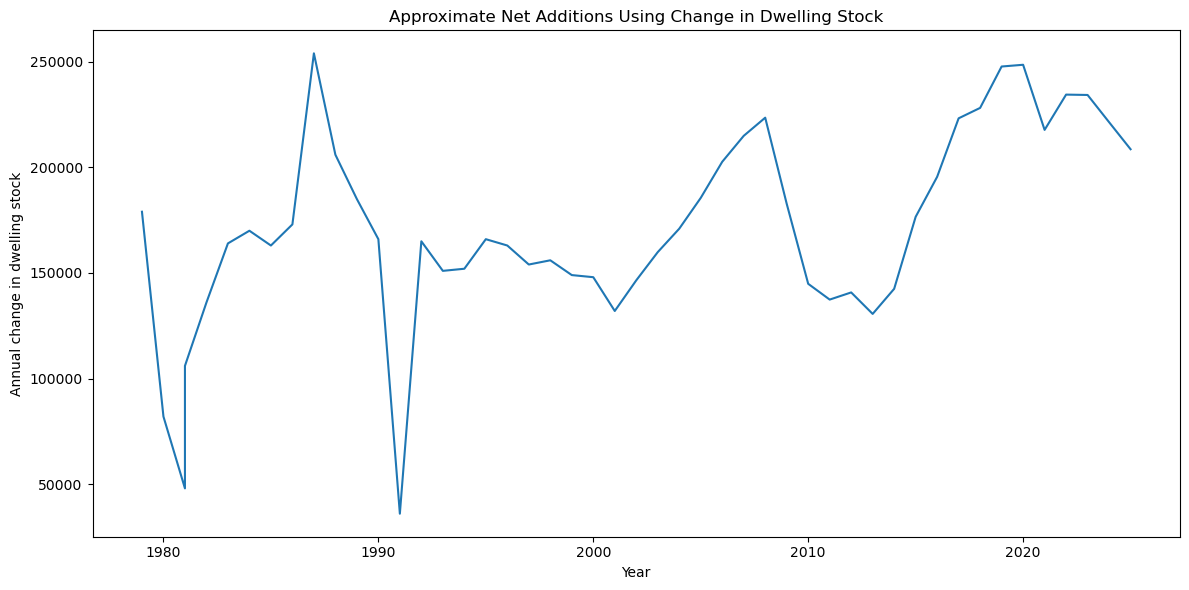

In [19]:
# Save approximate net additions figure
plt.figure(figsize=(12, 6))
plt.plot(stock["year"], stock["approx_net_additions"])
plt.title("Approximate Net Additions Using Change in Dwelling Stock")
plt.xlabel("Year")
plt.ylabel("Annual change in dwelling stock")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "approx_net_additions_stock_change.png", dpi=300)
plt.show()

In [20]:
# Convert quarterly completions into annual completions
annual_completions = df.copy()

annual_completions["year"] = annual_completions.index.year

annual_completions = annual_completions.groupby("year", as_index=False).agg({
    "completions_all": "sum",
    "starts_all": "sum"
})

annual_completions = annual_completions.rename(columns={
    "completions_all": "annual_completions",
    "starts_all": "annual_starts"
})

annual_completions.head()

,year,annual_completions,annual_starts
0,1978,241310,226690
1,1979,209460,190580
2,1980,202610,129740
3,1981,168420,130760
4,1982,146670,165660


In [21]:
# Merge annual completions with dwelling stock change proxy
annual_bridge = pd.merge(
    annual_completions,
    stock[["year", "dwelling_stock", "approx_net_additions"]],
    on="year",
    how="inner"
)

annual_bridge.head()

,year,annual_completions,annual_starts,dwelling_stock,approx_net_additions
0,1978,241310,226690,17603000.0,NaN
1,1979,209460,190580,17782000.0,179000.0
2,1980,202610,129740,17864000.0,82000.0
3,1981,168420,130760,17912000.0,48000.0
4,1981,168420,130760,18018000.0,106000.0


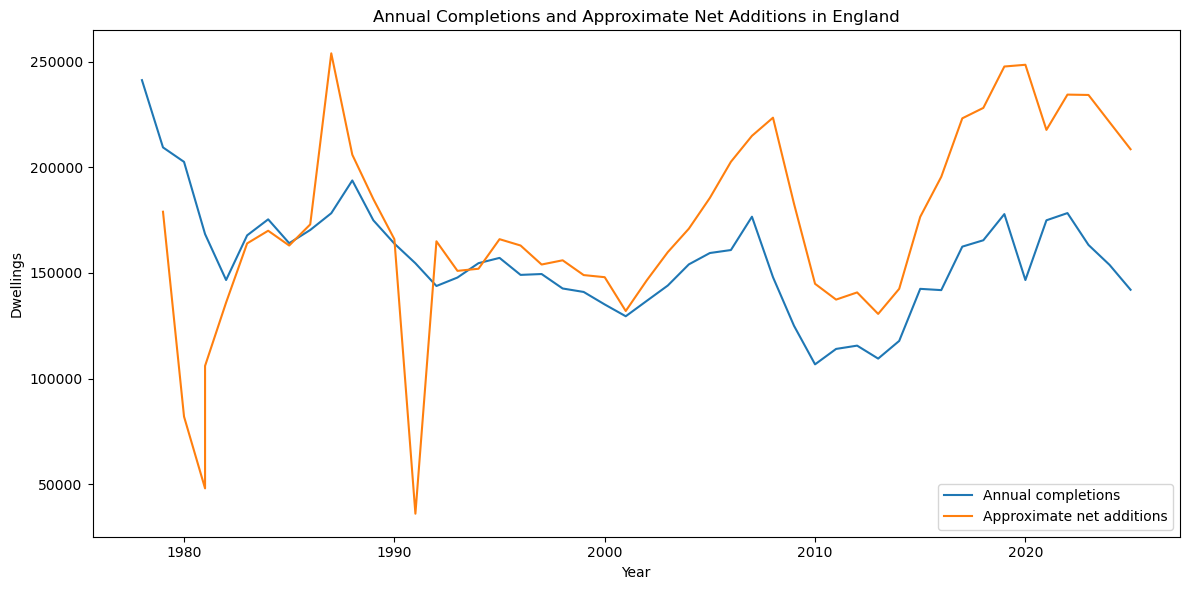

In [22]:
# Plot annual completions and approximate net additions
plt.figure(figsize=(12, 6))
plt.plot(annual_bridge["year"], annual_bridge["annual_completions"], label="Annual completions")
plt.plot(annual_bridge["year"], annual_bridge["approx_net_additions"], label="Approximate net additions")
plt.title("Annual Completions and Approximate Net Additions in England")
plt.xlabel("Year")
plt.ylabel("Dwellings")
plt.legend()
plt.tight_layout()
plt.show()

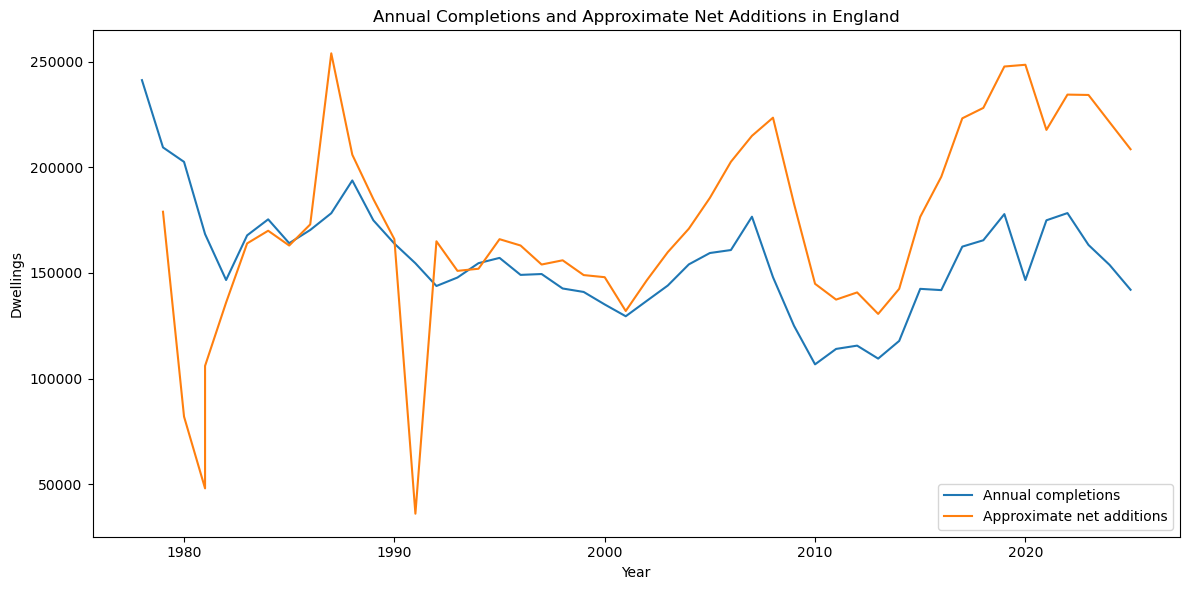

In [23]:
# Save annual bridge figure
plt.figure(figsize=(12, 6))
plt.plot(annual_bridge["year"], annual_bridge["annual_completions"], label="Annual completions")
plt.plot(annual_bridge["year"], annual_bridge["approx_net_additions"], label="Approximate net additions")
plt.title("Annual Completions and Approximate Net Additions in England")
plt.xlabel("Year")
plt.ylabel("Dwellings")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "annual_completions_vs_net_additions_proxy.png", dpi=300)
plt.show()

In [24]:
# ============================================================
# Save Net Supply Proxy Datasets
# ============================================================

stock.to_excel(
    OUTPUT_DIR / "dwelling_stock_proxy_data.xlsx",
    index=False
)

annual_bridge.to_excel(
    OUTPUT_DIR / "annual_completions_net_supply_bridge.xlsx",
    index=False
)

print("Net supply proxy datasets saved successfully.")

Net supply proxy datasets saved successfully.


In [25]:
# ============================================================
# Completion Lag Selection - Common Sample
# Preferred Shock Specification
#
# Compare 1-4 completion lags using the SAME observations
# Private starts lag fixed at 1 quarter
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

from statsmodels.stats.diagnostic import (
    acorr_ljungbox
)


# ============================================================
# 1. Create modelling dataset
# ============================================================

completion_df = df.copy()

completion_df = completion_df[
    (completion_df["starts_private"] > 0) &
    (completion_df["completions_private"] > 0)
].copy()


# ============================================================
# 2. Log transformations
# ============================================================

completion_df["ln_C_private"] = np.log(
    completion_df["completions_private"]
)

completion_df["ln_S_private"] = np.log(
    completion_df["starts_private"]
)


# ============================================================
# 3. Completion lags 1-4
# ============================================================

for lag in range(1, 5):

    completion_df[f"ln_C_private_lag{lag}"] = (
        completion_df["ln_C_private"].shift(lag)
    )


# ============================================================
# 4. Private starts lag = 1 quarter
# ============================================================

completion_df["ln_S_private_lag1"] = (
    completion_df["ln_S_private"].shift(1)
)


# ============================================================
# 5. Quarterly seasonality
# ============================================================

completion_df["quarter_num"] = (
    completion_df.index.quarter
)


# ============================================================
# 6. Preferred historical shock controls
# ============================================================

completion_df["gfc_2008_2009"] = (
    (completion_df.index >= pd.Period("2008Q3", freq="Q")) &
    (completion_df.index <= pd.Period("2009Q4", freq="Q"))
).astype(int)

completion_df["covid_2020Q2"] = (
    completion_df.index == pd.Period("2020Q2", freq="Q")
).astype(int)

completion_df["covid_2020Q3"] = (
    completion_df.index == pd.Period("2020Q3", freq="Q")
).astype(int)

completion_df["covid_2020Q4"] = (
    completion_df.index == pd.Period("2020Q4", freq="Q")
).astype(int)


# ============================================================
# 7. Common sample
# ============================================================

required_cols = [
    "ln_C_private",
    "ln_C_private_lag1",
    "ln_C_private_lag2",
    "ln_C_private_lag3",
    "ln_C_private_lag4",
    "ln_S_private_lag1",
    "quarter_num",
    "gfc_2008_2009",
    "covid_2020Q2",
    "covid_2020Q3",
    "covid_2020Q4"
]

completion_df = completion_df.dropna(
    subset=required_cols
).copy()


print("==========================================")
print("COMMON SAMPLE CREATED")
print("==========================================")

print("Observations:", len(completion_df))

print(
    "Sample period:",
    completion_df.index.min(),
    "to",
    completion_df.index.max()
)


# ============================================================
# 8. Compare completion lag specifications 1-4
# ============================================================

completion_lag_results_common = []

for p in range(1, 5):

    completion_terms = " + ".join(
        [
            f"ln_C_private_lag{lag}"
            for lag in range(1, p + 1)
        ]
    )

    formula = f"""
    ln_C_private ~ {completion_terms}
    + ln_S_private_lag1
    + C(quarter_num)
    + gfc_2008_2009
    + covid_2020Q2
    + covid_2020Q3
    + covid_2020Q4
    """

    model_p = smf.ols(
        formula,
        data=completion_df
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 4}
    )

    lb = acorr_ljungbox(
        model_p.resid,
        lags=[4, 8, 12],
        return_df=True
    )

    completion_lag_results_common.append({

        "Completion_Lags": p,

        "Starts_Coefficient":
            model_p.params["ln_S_private_lag1"],

        "Starts_P_value":
            model_p.pvalues["ln_S_private_lag1"],

        "Adj_R_squared":
            model_p.rsquared_adj,

        "AIC":
            model_p.aic,

        "BIC":
            model_p.bic,

        "LB_pvalue_4":
            lb.loc[4, "lb_pvalue"],

        "LB_pvalue_8":
            lb.loc[8, "lb_pvalue"],

        "LB_pvalue_12":
            lb.loc[12, "lb_pvalue"]
    })


# ============================================================
# 9. Results table
# ============================================================

completion_lag_results_common = pd.DataFrame(
    completion_lag_results_common
)

print("\n==========================================")
print("COMPLETION LAG SELECTION RESULTS")
print("==========================================")

print(
    completion_lag_results_common
    .round(6)
    .to_string(index=False)
)


# ============================================================
# 10. Select preferred specification
# ============================================================

best_completion_adj_r2 = (
    completion_lag_results_common.loc[
        completion_lag_results_common[
            "Adj_R_squared"
        ].idxmax()
    ]
)

best_completion_aic = (
    completion_lag_results_common.loc[
        completion_lag_results_common[
            "AIC"
        ].idxmin()
    ]
)

best_completion_bic = (
    completion_lag_results_common.loc[
        completion_lag_results_common[
            "BIC"
        ].idxmin()
    ]
)


print("\n==========================================")
print("SELECTED COMPLETION-LAG SPECIFICATION")
print("==========================================")

print(
    "Completion lags:",
    int(best_completion_adj_r2["Completion_Lags"])
)

print(
    "Adjusted R-squared:",
    best_completion_adj_r2["Adj_R_squared"]
)

print(
    "AIC:",
    best_completion_adj_r2["AIC"]
)

print(
    "BIC:",
    best_completion_adj_r2["BIC"]
)

print(
    "Ljung-Box p-value (lag 4):",
    best_completion_adj_r2["LB_pvalue_4"]
)

print(
    "Ljung-Box p-value (lag 8):",
    best_completion_adj_r2["LB_pvalue_8"]
)

print(
    "Ljung-Box p-value (lag 12):",
    best_completion_adj_r2["LB_pvalue_12"]
)

COMMON SAMPLE CREATED
Observations: 188
Sample period: 1979Q1 to 2025Q4

COMPLETION LAG SELECTION RESULTS
 Completion_Lags  Starts_Coefficient  Starts_P_value  Adj_R_squared         AIC         BIC  LB_pvalue_4  LB_pvalue_8  LB_pvalue_12
               1            0.209781             0.0       0.812120 -392.668817 -360.304398     0.000000     0.000000      0.000000
               2            0.201572             0.0       0.861962 -449.683449 -414.082588     0.072615     0.055672      0.040709
               3            0.202104             0.0       0.861252 -447.783869 -408.946565     0.084177     0.064474      0.048877
               4            0.215901             0.0       0.867962 -456.174933 -414.101187     0.792063     0.685697      0.509320

SELECTED COMPLETION-LAG SPECIFICATION
Completion lags: 4
Adjusted R-squared: 0.8679620598721706
AIC: -456.1749325578369
BIC: -414.1011870410475
Ljung-Box p-value (lag 4): 0.7920633141814898
Ljung-Box p-value (lag 8): 0.68569677345676

In [26]:
# ============================================================
# Robustness Check:
# Original Shock Controls vs Group Impulse Dummies
# Final dynamic structure:
# Starts lag = 1
# Completion lags = 1-4
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_ljungbox


# ============================================================
# 1. Create common comparison dataset
# ============================================================

compare_df = df.copy()

compare_df = compare_df[
    (compare_df["starts_private"] > 0) &
    (compare_df["completions_private"] > 0)
].copy()

compare_df["ln_C_private"] = np.log(
    compare_df["completions_private"]
)

compare_df["ln_S_private"] = np.log(
    compare_df["starts_private"]
)

# Completion lags 1-4
for lag in range(1, 5):
    compare_df[f"ln_C_private_lag{lag}"] = (
        compare_df["ln_C_private"].shift(lag)
    )

# Starts lag 1
compare_df["ln_S_private_lag1"] = (
    compare_df["ln_S_private"].shift(1)
)

# Seasonality
compare_df["quarter_num"] = compare_df.index.quarter


# ============================================================
# 2. Original shock controls
# ============================================================

compare_df["gfc_2008_2009"] = (
    (compare_df.index >= pd.Period("2008Q3", freq="Q")) &
    (compare_df.index <= pd.Period("2009Q4", freq="Q"))
).astype(int)

compare_df["covid_2020Q2"] = (
    compare_df.index == pd.Period("2020Q2", freq="Q")
).astype(int)

compare_df["covid_2020Q3"] = (
    compare_df.index == pd.Period("2020Q3", freq="Q")
).astype(int)

compare_df["covid_2020Q4"] = (
    compare_df.index == pd.Period("2020Q4", freq="Q")
).astype(int)


# ============================================================
# 3. Group impulse dummies
# ============================================================

compare_df["d08Q3"] = (
    compare_df.index == pd.Period("2008Q3", freq="Q")
).astype(int)

compare_df["d20Q2"] = (
    compare_df.index == pd.Period("2020Q2", freq="Q")
).astype(int)

compare_df["d20Q3"] = (
    compare_df.index == pd.Period("2020Q3", freq="Q")
).astype(int)

compare_df["d23Q2"] = (
    compare_df.index == pd.Period("2023Q2", freq="Q")
).astype(int)

compare_df["d23Q3"] = (
    compare_df.index == pd.Period("2023Q3", freq="Q")
).astype(int)


# ============================================================
# 4. Use exactly the same sample
# ============================================================

required_cols = [
    "ln_C_private",
    "ln_C_private_lag1",
    "ln_C_private_lag2",
    "ln_C_private_lag3",
    "ln_C_private_lag4",
    "ln_S_private_lag1",
    "quarter_num"
]

compare_df = compare_df.dropna(
    subset=required_cols
).copy()


# ============================================================
# 5. Original preferred specification
# ============================================================

original_formula = """
ln_C_private ~ ln_C_private_lag1
+ ln_C_private_lag2
+ ln_C_private_lag3
+ ln_C_private_lag4
+ ln_S_private_lag1
+ C(quarter_num)
+ gfc_2008_2009
+ covid_2020Q2
+ covid_2020Q3
+ covid_2020Q4
"""

original_model = smf.ols(
    original_formula,
    data=compare_df
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)


# ============================================================
# 6. Group impulse-dummy specification
# ============================================================

group_formula = """
ln_C_private ~ ln_C_private_lag1
+ ln_C_private_lag2
+ ln_C_private_lag3
+ ln_C_private_lag4
+ ln_S_private_lag1
+ C(quarter_num)
+ d08Q3
+ d20Q2
+ d20Q3
+ d23Q2
+ d23Q3
"""

group_model = smf.ols(
    group_formula,
    data=compare_df
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)


# ============================================================
# 7. Ljung-Box diagnostics
# ============================================================

lb_original = acorr_ljungbox(
    original_model.resid,
    lags=[4, 8, 12],
    return_df=True
)

lb_group = acorr_ljungbox(
    group_model.resid,
    lags=[4, 8, 12],
    return_df=True
)


# ============================================================
# 8. Comparison table
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Original shock controls",
        "Group impulse dummies"
    ],

    "Observations": [
        int(original_model.nobs),
        int(group_model.nobs)
    ],

    "Adj_R_squared": [
        original_model.rsquared_adj,
        group_model.rsquared_adj
    ],

    "AIC": [
        original_model.aic,
        group_model.aic
    ],

    "BIC": [
        original_model.bic,
        group_model.bic
    ],

    "Starts_Coefficient": [
        original_model.params["ln_S_private_lag1"],
        group_model.params["ln_S_private_lag1"]
    ],

    "Starts_P_value": [
        original_model.pvalues["ln_S_private_lag1"],
        group_model.pvalues["ln_S_private_lag1"]
    ],

    "LB_pvalue_4": [
        lb_original.loc[4, "lb_pvalue"],
        lb_group.loc[4, "lb_pvalue"]
    ],

    "LB_pvalue_8": [
        lb_original.loc[8, "lb_pvalue"],
        lb_group.loc[8, "lb_pvalue"]
    ],

    "LB_pvalue_12": [
        lb_original.loc[12, "lb_pvalue"],
        lb_group.loc[12, "lb_pvalue"]
    ]
})


print("==========================================")
print("SHOCK SPECIFICATION ROBUSTNESS CHECK")
print("==========================================")

print(
    comparison.to_string(index=False)
)

SHOCK SPECIFICATION ROBUSTNESS CHECK
                  Model  Observations  Adj_R_squared         AIC         BIC  Starts_Coefficient  Starts_P_value  LB_pvalue_4  LB_pvalue_8  LB_pvalue_12
Original shock controls           188       0.867962 -456.174933 -414.101187            0.215901    2.886397e-09     0.792063     0.685697       0.50932
  Group impulse dummies           188       0.848355 -429.223712 -383.913524            0.218165    7.725005e-13     0.148826     0.093477       0.03164


In [27]:
# ============================================================
# Final Preferred Dynamic Starts-to-Completions Model
#
# Private starts lag: 1 quarter
# Private completion lags: 1-4 quarters
#
# Preferred shock specification:
# GFC 2008Q3-2009Q4
# COVID 2020Q2, 2020Q3 and 2020Q4
# Quarterly seasonality
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf


# ============================================================
# 1. Add preferred historical shock controls
# ============================================================

completion_df["gfc_2008_2009"] = (
    (completion_df.index >= pd.Period("2008Q3", freq="Q")) &
    (completion_df.index <= pd.Period("2009Q4", freq="Q"))
).astype(int)

completion_df["covid_2020Q2"] = (
    completion_df.index == pd.Period("2020Q2", freq="Q")
).astype(int)

completion_df["covid_2020Q3"] = (
    completion_df.index == pd.Period("2020Q3", freq="Q")
).astype(int)

completion_df["covid_2020Q4"] = (
    completion_df.index == pd.Period("2020Q4", freq="Q")
).astype(int)


# ============================================================
# 2. Final preferred model specification
# ============================================================

preferred_formula = """
ln_C_private ~ ln_C_private_lag1
+ ln_C_private_lag2
+ ln_C_private_lag3
+ ln_C_private_lag4
+ ln_S_private_lag1
+ C(quarter_num)
+ gfc_2008_2009
+ covid_2020Q2
+ covid_2020Q3
+ covid_2020Q4
"""


# ============================================================
# 3. Estimate final model
# HAC / Newey-West standard errors
# ============================================================

preferred_model = smf.ols(
    preferred_formula,
    data=completion_df
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)


# ============================================================
# 4. Display final model
# ============================================================

print("==========================================")
print("FINAL PREFERRED DYNAMIC BRIDGE MODEL")
print("==========================================")

print("Starts lag: 1 quarter")
print("Completion lags: 1-4 quarters")
print("Observations:", int(preferred_model.nobs))

print(
    "Sample period:",
    completion_df.index.min(),
    "to",
    completion_df.index.max()
)

print("\nShock controls:")
print("GFC: 2008Q3-2009Q4")
print("COVID: 2020Q2, 2020Q3, 2020Q4")
print("Quarterly seasonality included")

print("\n==========================================")
print("MODEL SUMMARY")
print("==========================================")

print(preferred_model.summary())


# ============================================================
# 5. Key model statistics
# ============================================================

print("\n==========================================")
print("KEY MODEL STATISTICS")
print("==========================================")

print(
    "R-squared:",
    preferred_model.rsquared
)

print(
    "Adjusted R-squared:",
    preferred_model.rsquared_adj
)

print(
    "AIC:",
    preferred_model.aic
)

print(
    "BIC:",
    preferred_model.bic
)

print(
    "Starts coefficient:",
    preferred_model.params["ln_S_private_lag1"]
)

print(
    "Starts p-value:",
    preferred_model.pvalues["ln_S_private_lag1"]
)

FINAL PREFERRED DYNAMIC BRIDGE MODEL
Starts lag: 1 quarter
Completion lags: 1-4 quarters
Observations: 188
Sample period: 1979Q1 to 2025Q4

Shock controls:
GFC: 2008Q3-2009Q4
COVID: 2020Q2, 2020Q3, 2020Q4
Quarterly seasonality included

MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:           ln_C_private   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     541.9
Date:                Wed, 19 Aug 2026   Prob (F-statistic):          5.29e-126
Time:                        22:10:02   Log-Likelihood:                 241.09
No. Observations:                 188   AIC:                            -456.2
Df Residuals:                     175   BIC:                            -414.1
Df Model:                          12                                         
Covariance Type:                  HAC 

D:\shabibiancheng\Lib\site-packages\statsmodels\base\model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 10
  warnings.warn('covariance of constraints does not have full '


In [28]:
# ============================================================
# Final Model Diagnostic Tests
# Dynamic Starts-to-Completions Bridge Model
#
# Starts lag: 1 quarter
# Completion lags: 1-4 quarters
# Preferred historical shock controls
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_breuschpagan
)

from statsmodels.stats.stattools import (
    jarque_bera,
    durbin_watson
)


# ============================================================
# 1. Residuals from final preferred model
# ============================================================

resid = preferred_model.resid


# ============================================================
# 2. Ljung-Box Test
# H0: no residual autocorrelation
# ============================================================

ljung_box = acorr_ljungbox(
    resid,
    lags=[4, 8, 12],
    return_df=True
)

print("==========================================")
print("LJUNG-BOX TEST")
print("==========================================")
print(ljung_box)


# ============================================================
# 3. Durbin-Watson Statistic
# ============================================================

dw_stat = durbin_watson(resid)

print("\n==========================================")
print("DURBIN-WATSON STATISTIC")
print("==========================================")
print("Durbin-Watson:", dw_stat)


# ============================================================
# 4. Breusch-Pagan Test
# H0: homoskedastic residuals
# ============================================================

bp_test = het_breuschpagan(
    resid,
    preferred_model.model.exog
)

bp_results = pd.Series(
    bp_test,
    index=[
        "LM statistic",
        "LM p-value",
        "F statistic",
        "F p-value"
    ]
)

print("\n==========================================")
print("BREUSCH-PAGAN TEST")
print("==========================================")
print(bp_results)


# ============================================================
# 5. Jarque-Bera Test
# H0: normally distributed residuals
# ============================================================

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(
    resid
)

print("\n==========================================")
print("JARQUE-BERA TEST")
print("==========================================")

print("JB statistic:", jb_stat)
print("p-value:", jb_pvalue)
print("Skewness:", skew)
print("Kurtosis:", kurtosis)


# ============================================================
# 6. Ramsey RESET Test
# H0: no functional-form misspecification
# ============================================================

reset_df = completion_df.copy()

reset_df["fitted_sq"] = (
    np.asarray(preferred_model.fittedvalues) ** 2
)

reset_formula = """
ln_C_private ~ ln_C_private_lag1
+ ln_C_private_lag2
+ ln_C_private_lag3
+ ln_C_private_lag4
+ ln_S_private_lag1
+ C(quarter_num)
+ gfc_2008_2009
+ covid_2020Q2
+ covid_2020Q3
+ covid_2020Q4
+ fitted_sq
"""

reset_model = smf.ols(
    reset_formula,
    data=reset_df
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)

reset_test = reset_model.f_test(
    "fitted_sq = 0"
)

reset_fvalue = float(
    np.asarray(reset_test.fvalue).squeeze()
)

reset_pvalue = float(
    np.asarray(reset_test.pvalue).squeeze()
)

print("\n==========================================")
print("RAMSEY RESET TEST")
print("==========================================")

print("F statistic:", reset_fvalue)
print("p-value:", reset_pvalue)


# ============================================================
# 7. Compact Diagnostic Summary
# ============================================================

diagnostic_summary = pd.DataFrame({

    "Diagnostic": [
        "Ljung-Box (lag 4)",
        "Ljung-Box (lag 8)",
        "Ljung-Box (lag 12)",
        "Breusch-Pagan LM",
        "Breusch-Pagan F",
        "Jarque-Bera",
        "Ramsey RESET",
        "Durbin-Watson"
    ],

    "Statistic_or_p_value": [
        ljung_box.loc[4, "lb_pvalue"],
        ljung_box.loc[8, "lb_pvalue"],
        ljung_box.loc[12, "lb_pvalue"],
        bp_results["LM p-value"],
        bp_results["F p-value"],
        jb_pvalue,
        reset_pvalue,
        dw_stat
    ]
})


print("\n==========================================")
print("FINAL DIAGNOSTIC SUMMARY")
print("==========================================")

print(
    diagnostic_summary.to_string(index=False)
)

LJUNG-BOX TEST
      lb_stat  lb_pvalue
4    1.692589   0.792063
8    5.656047   0.685697
12  11.229964   0.509320

DURBIN-WATSON STATISTIC
Durbin-Watson: 2.0433867272768107

BREUSCH-PAGAN TEST
LM statistic    8.204607
LM p-value      0.768944
F statistic     0.665482
F p-value       0.782800
dtype: float64

JARQUE-BERA TEST
JB statistic: 16.77168738885337
p-value: 0.00022807325325006672
Skewness: 0.3483484353196341
Kurtosis: 4.286732274256856

RAMSEY RESET TEST
F statistic: 0.29136039965068705
p-value: 0.5900401872617624

FINAL DIAGNOSTIC SUMMARY
        Diagnostic  Statistic_or_p_value
 Ljung-Box (lag 4)              0.792063
 Ljung-Box (lag 8)              0.685697
Ljung-Box (lag 12)              0.509320
  Breusch-Pagan LM              0.768944
   Breusch-Pagan F              0.782800
       Jarque-Bera              0.000228
      Ramsey RESET              0.590040
     Durbin-Watson              2.043387


In [29]:
# ============================================================
# Multicollinearity Check
# Variance Inflation Factor (VIF)
# Final Preferred Dynamic Starts-to-Completions Model
# ============================================================

import pandas as pd

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)


# ============================================================
# 1. Explanatory-variable matrix
# ============================================================

X = preferred_model.model.exog

variable_names = preferred_model.model.exog_names


# ============================================================
# 2. Calculate VIF
# ============================================================

vif_table = pd.DataFrame({

    "Variable": variable_names,

    "VIF": [
        variance_inflation_factor(X, i)
        for i in range(X.shape[1])
    ]
})


# ============================================================
# 3. Add simple interpretation
# ============================================================

def interpret_vif(row):

    # Intercept VIF is not substantively interpreted
    if row["Variable"] == "Intercept":
        return "Ignore intercept"

    if row["VIF"] < 5:
        return "Low"

    elif row["VIF"] < 10:
        return "Moderate"

    else:
        return "High"


vif_table["Interpretation"] = (
    vif_table.apply(
        interpret_vif,
        axis=1
    )
)


# ============================================================
# 4. Display results
# ============================================================

print("==========================================")
print("VARIANCE INFLATION FACTOR (VIF)")
print("==========================================")

print(
    vif_table.to_string(
        index=False
    )
)


# ============================================================
# 5. Maximum VIF excluding intercept
# ============================================================

vif_without_intercept = vif_table[
    vif_table["Variable"] != "Intercept"
].copy()

max_vif_row = vif_without_intercept.loc[
    vif_without_intercept["VIF"].idxmax()
]


print("\n==========================================")
print("VIF SUMMARY")
print("==========================================")

print(
    "Highest non-intercept VIF:",
    max_vif_row["Variable"]
)

print(
    "VIF:",
    max_vif_row["VIF"]
)

VARIANCE INFLATION FACTOR (VIF)
           Variable         VIF   Interpretation
          Intercept 4276.201154 Ignore intercept
C(quarter_num)[T.2]    3.939487              Low
C(quarter_num)[T.3]    2.891066              Low
C(quarter_num)[T.4]    3.519666              Low
  ln_C_private_lag1    6.444223         Moderate
  ln_C_private_lag2    6.216003         Moderate
  ln_C_private_lag3    3.770926              Low
  ln_C_private_lag4    3.382167              Low
  ln_S_private_lag1    2.735109              Low
      gfc_2008_2009    1.365528              Low
       covid_2020Q2    1.039140              Low
       covid_2020Q3    1.590573              Low
       covid_2020Q4    1.762660              Low

VIF SUMMARY
Highest non-intercept VIF: ln_C_private_lag1
VIF: 6.444222624683344


In [30]:
# ============================================================
# Dynamic Stability Check
# AR(4) Completion Dynamics
# Final Preferred Starts-to-Completions Model
# ============================================================

import numpy as np


# ============================================================
# 1. Extract coefficients on lagged completions
# ============================================================

phi1 = preferred_model.params[
    "ln_C_private_lag1"
]

phi2 = preferred_model.params[
    "ln_C_private_lag2"
]

phi3 = preferred_model.params[
    "ln_C_private_lag3"
]

phi4 = preferred_model.params[
    "ln_C_private_lag4"
]


# ============================================================
# 2. Display AR coefficients
# ============================================================

print("==========================================")
print("AR(4) COMPLETION COEFFICIENTS")
print("==========================================")

print("phi1 =", phi1)
print("phi2 =", phi2)
print("phi3 =", phi3)
print("phi4 =", phi4)


# ============================================================
# 3. Construct AR(4) companion matrix
# ============================================================

companion_matrix = np.array([
    [phi1, phi2, phi3, phi4],
    [1.0,  0.0,  0.0,  0.0],
    [0.0,  1.0,  0.0,  0.0],
    [0.0,  0.0,  1.0,  0.0]
])


# ============================================================
# 4. Calculate eigenvalues
# ============================================================

eigenvalues = np.linalg.eigvals(
    companion_matrix
)

modulus = np.abs(
    eigenvalues
)


# ============================================================
# 5. Display stability results
# ============================================================

print("\n==========================================")
print("DYNAMIC STABILITY CHECK")
print("==========================================")

print("\nAR eigenvalues:")
print(eigenvalues)

print("\nModulus of eigenvalues:")
print(modulus)

print("\nMaximum modulus:")
print(modulus.max())


# ============================================================
# 6. Stability conclusion
# ============================================================

if np.all(modulus < 1):

    print("\nRESULT: Dynamic specification is STABLE.")
    print(
        "All eigenvalues lie inside the unit circle."
    )

else:

    print("\nRESULT: Dynamic specification is NOT STABLE.")
    print(
        "At least one eigenvalue lies on or outside "
        "the unit circle."
    )


# ============================================================
# 7. Compact stability summary
# ============================================================

print("\n==========================================")
print("STABILITY SUMMARY")
print("==========================================")

print(
    "Maximum eigenvalue modulus:",
    modulus.max()
)

print(
    "Stable:",
    bool(np.all(modulus < 1))
)

AR(4) COMPLETION COEFFICIENTS
phi1 = 0.21162400017134764
phi2 = 0.39203686523706666
phi3 = -0.032242172744269715
phi4 = 0.15550081464465015

DYNAMIC STABILITY CHECK

AR eigenvalues:
[ 0.86368   +0.j         -0.74611465+0.j          0.04702932+0.48897612j
  0.04702932-0.48897612j]

Modulus of eigenvalues:
[0.86368    0.74611465 0.49123253 0.49123253]

Maximum modulus:
0.863680001988671

RESULT: Dynamic specification is STABLE.
All eigenvalues lie inside the unit circle.

STABILITY SUMMARY
Maximum eigenvalue modulus: 0.863680001988671
Stable: True


SMEARING CORRECTION
Smearing factor: 1.002273597136804


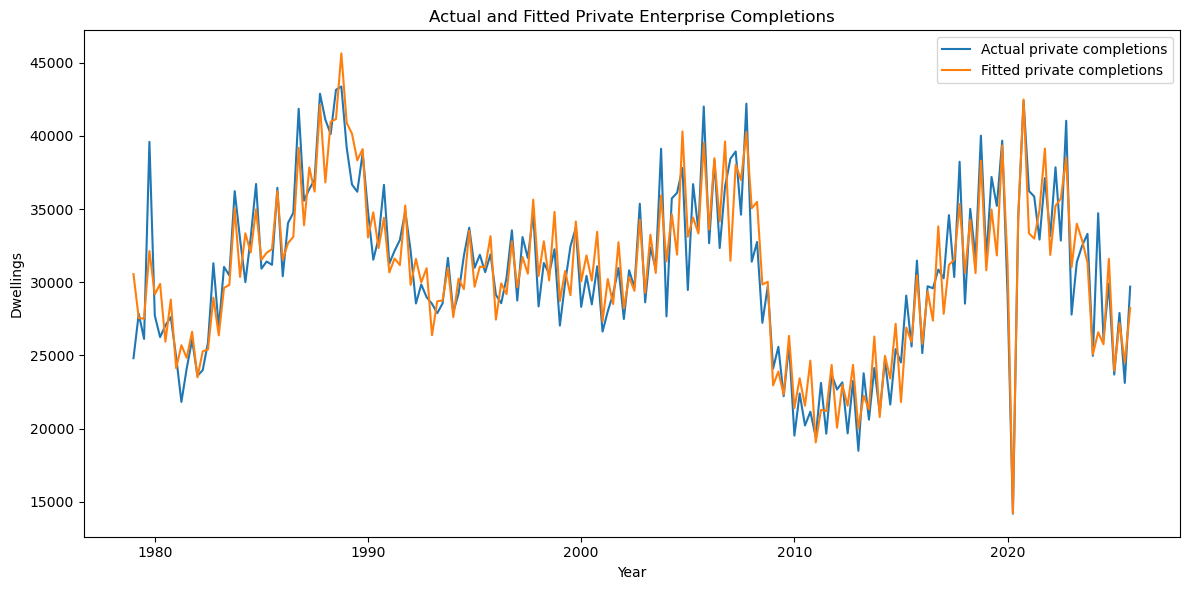


Figure saved successfully.


In [31]:
# ============================================================
# Actual vs Fitted Private Enterprise Completions
# Final Preferred AR(4) Starts-to-Completions Model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. Generate fitted log private completions
# ============================================================

completion_df["fitted_ln_C_private"] = (
    preferred_model.predict(completion_df)
)


# ============================================================
# 2. Smearing correction
# Convert fitted log values back to dwelling levels
# ============================================================

smearing_factor = np.mean(
    np.exp(preferred_model.resid)
)

completion_df["fitted_C_private"] = (
    np.exp(completion_df["fitted_ln_C_private"])
    * smearing_factor
)


# ============================================================
# 3. Actual private completions in levels
# ============================================================

completion_df["actual_C_private"] = (
    np.exp(completion_df["ln_C_private"])
)


# ============================================================
# 4. Convert quarterly index to dates for plotting
# ============================================================

completion_df["date"] = (
    completion_df.index.to_timestamp()
)


# ============================================================
# 5. Display smearing factor
# ============================================================

print("==========================================")
print("SMEARING CORRECTION")
print("==========================================")

print(
    "Smearing factor:",
    smearing_factor
)


# ============================================================
# 6. Plot Actual vs Fitted
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    completion_df["date"],
    completion_df["actual_C_private"],
    label="Actual private completions"
)

plt.plot(
    completion_df["date"],
    completion_df["fitted_C_private"],
    label="Fitted private completions"
)

plt.title(
    "Actual and Fitted Private Enterprise Completions"
)

plt.xlabel("Year")
plt.ylabel("Dwellings")

plt.legend()
plt.tight_layout()


# ============================================================
# 7. Save final figure
# ============================================================

OUTPUT_DIR = Path(r"D:\data\outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.savefig(
    OUTPUT_DIR / "final_actual_vs_fitted_private_completions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\nFigure saved successfully.")

In [32]:
# ============================================================
# Final Model Summary
# Final Preferred AR(4) Starts-to-Completions Bridge Model
# ============================================================

import pandas as pd


preferred_summary = pd.DataFrame({

    "Model": [
        "Dynamic Starts-to-Completions Bridge Model"
    ],

    "Dependent_variable": [
        "Log private enterprise completions"
    ],

    "Starts_lag": [
        "1 quarter"
    ],

    "Completion_lags": [
        "1-4 quarters"
    ],

    "Shock_controls": [
        "GFC 2008Q3-2009Q4; COVID 2020Q2-Q4"
    ],

    "Observations": [
        int(preferred_model.nobs)
    ],

    "R_squared": [
        preferred_model.rsquared
    ],

    "Adj_R_squared": [
        preferred_model.rsquared_adj
    ],

    "AIC": [
        preferred_model.aic
    ],

    "BIC": [
        preferred_model.bic
    ],

    "Starts_coefficient": [
        preferred_model.params["ln_S_private_lag1"]
    ],

    "Starts_p_value": [
        preferred_model.pvalues["ln_S_private_lag1"]
    ],

    "Smearing_factor": [
        smearing_factor
    ]
})


print("==========================================")
print("FINAL MODEL SUMMARY")
print("==========================================")

print(
    preferred_summary.to_string(index=False)
)

FINAL MODEL SUMMARY
                                     Model                 Dependent_variable Starts_lag Completion_lags                     Shock_controls  Observations  R_squared  Adj_R_squared         AIC         BIC  Starts_coefficient  Starts_p_value  Smearing_factor
Dynamic Starts-to-Completions Bridge Model Log private enterprise completions  1 quarter    1-4 quarters GFC 2008Q3-2009Q4; COVID 2020Q2-Q4           188   0.876435       0.867962 -456.174933 -414.101187            0.215901    2.886397e-09         1.002274


In [33]:
# ============================================================
# Final Regression Coefficient Table
# Final Preferred AR(4) Starts-to-Completions Model
# ============================================================

from pathlib import Path
import pandas as pd


# ============================================================
# 1. Output folder
# ============================================================

OUTPUT_DIR = Path(r"D:\data\outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# 2. Create coefficient table
# ============================================================

preferred_results_table = pd.DataFrame({

    "Variable": preferred_model.params.index,

    "Coefficient": preferred_model.params.values,

    "HAC_Std_Error": preferred_model.bse.values,

    "P_Value": preferred_model.pvalues.values,

    "CI_Lower_95": preferred_model.conf_int()[0].values,

    "CI_Upper_95": preferred_model.conf_int()[1].values
})


# ============================================================
# 3. Add significance stars
# ============================================================

def significance_star(p):

    if p < 0.01:
        return "***"

    elif p < 0.05:
        return "**"

    elif p < 0.10:
        return "*"

    else:
        return ""


preferred_results_table["Significance"] = (
    preferred_results_table["P_Value"]
    .apply(significance_star)
)


# ============================================================
# 4. Round values for readable output
# ============================================================

display_table = preferred_results_table.copy()

for col in [
    "Coefficient",
    "HAC_Std_Error",
    "P_Value",
    "CI_Lower_95",
    "CI_Upper_95"
]:
    display_table[col] = display_table[col].round(6)


# ============================================================
# 5. Display final coefficient table
# ============================================================

print("==========================================")
print("FINAL REGRESSION COEFFICIENT TABLE")
print("==========================================")

print(
    display_table.to_string(index=False)
)


# ============================================================
# 6. Save full-precision results
# ============================================================

preferred_results_table.to_excel(
    OUTPUT_DIR / "final_dynamic_bridge_model_coefficients.xlsx",
    index=False
)

preferred_summary.to_excel(
    OUTPUT_DIR / "final_dynamic_bridge_model_summary.xlsx",
    index=False
)


print(
    "\nCoefficient table and model summary saved successfully."
)

FINAL REGRESSION COEFFICIENT TABLE
           Variable  Coefficient  HAC_Std_Error  P_Value  CI_Lower_95  CI_Upper_95 Significance
          Intercept     0.551519       0.324736 0.089440    -0.084952     1.187990            *
C(quarter_num)[T.2]     0.029504       0.024988 0.237707    -0.019471     0.078479             
C(quarter_num)[T.3]     0.017449       0.023879 0.464950    -0.029353     0.064250             
C(quarter_num)[T.4]     0.110284       0.021630 0.000000     0.067890     0.152677          ***
  ln_C_private_lag1     0.211624       0.059749 0.000397     0.094518     0.328730          ***
  ln_C_private_lag2     0.392037       0.059340 0.000000     0.275732     0.508342          ***
  ln_C_private_lag3    -0.032242       0.055332 0.560094    -0.140691     0.076207             
  ln_C_private_lag4     0.155501       0.045410 0.000616     0.066500     0.244502          ***
  ln_S_private_lag1     0.215901       0.036360 0.000000     0.144637     0.287164          ***
     

In [34]:
# ============================================================
# Final Diagnostic Summary
# Final Preferred AR(4) Starts-to-Completions Model
# ============================================================

import pandas as pd


# ============================================================
# 1. Create final diagnostic reporting table
# ============================================================

final_diagnostic_table = pd.DataFrame({

    "Diagnostic": [
        "Ljung-Box (lag 4)",
        "Ljung-Box (lag 8)",
        "Ljung-Box (lag 12)",
        "Breusch-Pagan LM",
        "Breusch-Pagan F",
        "Jarque-Bera",
        "Ramsey RESET",
        "Durbin-Watson"
    ],

    "Value": [
        ljung_box.loc[4, "lb_pvalue"],
        ljung_box.loc[8, "lb_pvalue"],
        ljung_box.loc[12, "lb_pvalue"],
        bp_results["LM p-value"],
        bp_results["F p-value"],
        jb_pvalue,
        reset_pvalue,
        dw_stat
    ],

    "Interpretation": [
        "No residual autocorrelation",
        "No residual autocorrelation",
        "No residual autocorrelation",
        "No evidence of heteroskedasticity",
        "No evidence of heteroskedasticity",
        "Residuals reject normality",
        "No major functional-form misspecification",
        "Close to 2; little first-order autocorrelation"
    ]
})


# ============================================================
# 2. Display final diagnostic summary
# ============================================================

print("==========================================")
print("FINAL DIAGNOSTIC SUMMARY")
print("==========================================")

print(
    final_diagnostic_table
    .round(6)
    .to_string(index=False)
)


# ============================================================
# 3. Save diagnostic summary
# ============================================================

final_diagnostic_table.to_excel(
    OUTPUT_DIR / "final_model_diagnostic_tests.xlsx",
    index=False
)

print("\nDiagnostic summary saved successfully.")

FINAL DIAGNOSTIC SUMMARY
        Diagnostic    Value                                 Interpretation
 Ljung-Box (lag 4) 0.792063                    No residual autocorrelation
 Ljung-Box (lag 8) 0.685697                    No residual autocorrelation
Ljung-Box (lag 12) 0.509320                    No residual autocorrelation
  Breusch-Pagan LM 0.768944              No evidence of heteroskedasticity
   Breusch-Pagan F 0.782800              No evidence of heteroskedasticity
       Jarque-Bera 0.000228                     Residuals reject normality
      Ramsey RESET 0.590040      No major functional-form misspecification
     Durbin-Watson 2.043387 Close to 2; little first-order autocorrelation

Diagnostic summary saved successfully.


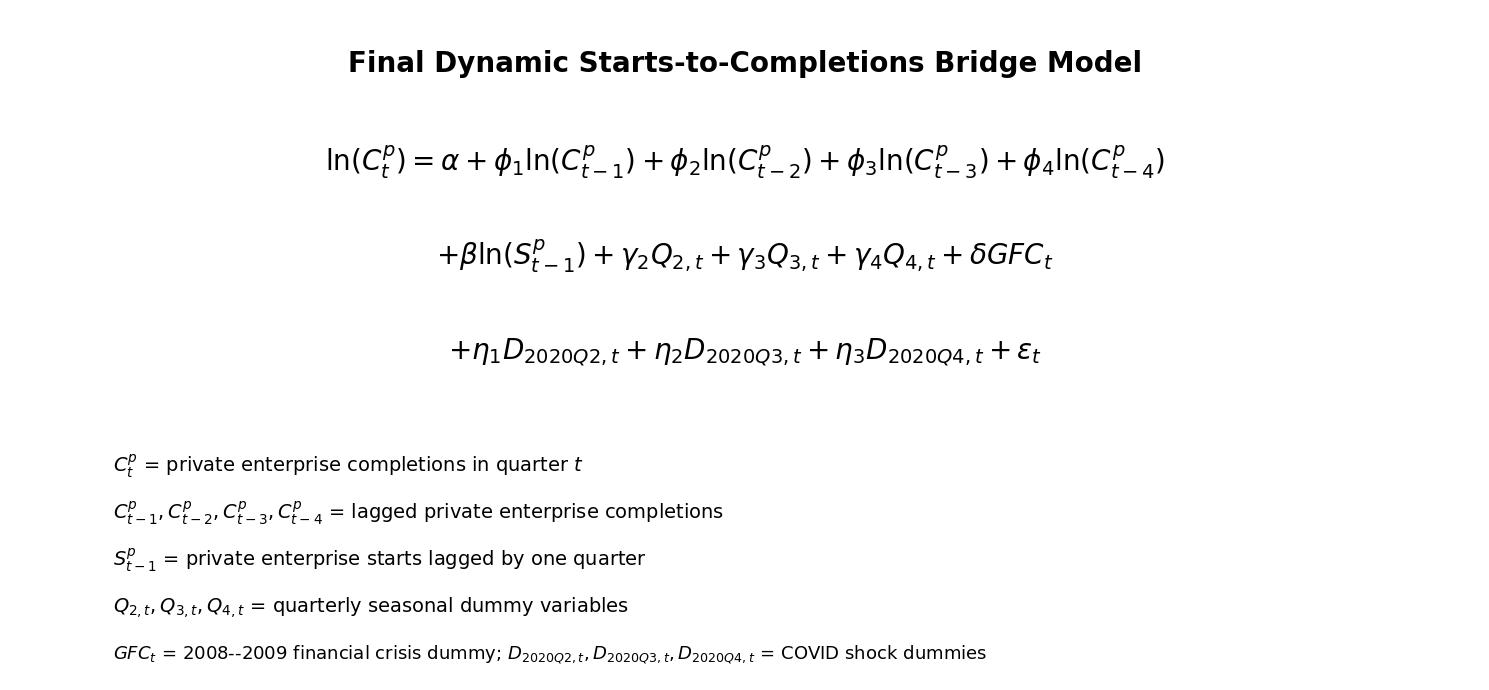

Final model equation figure saved successfully.


In [35]:
# ============================================================
# Final Model Equation Figure
# Final Preferred AR(4) Starts-to-Completions Model
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path(r"D:\data\outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(15, 7))
ax.axis("off")


# ============================================================
# Title
# ============================================================

ax.text(
    0.5,
    0.94,
    "Final Dynamic Starts-to-Completions Bridge Model",
    fontsize=20,
    fontweight="bold",
    ha="center",
    va="top"
)


# ============================================================
# Equation - Line 1
# ============================================================

ax.text(
    0.5,
    0.76,
    r"$\ln(C_t^p)"
    r" = \alpha"
    r" + \phi_1\ln(C_{t-1}^p)"
    r" + \phi_2\ln(C_{t-2}^p)"
    r" + \phi_3\ln(C_{t-3}^p)"
    r" + \phi_4\ln(C_{t-4}^p)$",
    fontsize=20,
    ha="center"
)


# ============================================================
# Equation - Line 2
# ============================================================

ax.text(
    0.5,
    0.62,
    r"$+ \beta\ln(S_{t-1}^p)"
    r" + \gamma_2Q_{2,t}"
    r" + \gamma_3Q_{3,t}"
    r" + \gamma_4Q_{4,t}"
    r" + \delta GFC_t$",
    fontsize=20,
    ha="center"
)


# ============================================================
# Equation - Line 3
# ============================================================

ax.text(
    0.5,
    0.48,
    r"$+ \eta_1D_{2020Q2,t}"
    r" + \eta_2D_{2020Q3,t}"
    r" + \eta_3D_{2020Q4,t}"
    r" + \varepsilon_t$",
    fontsize=20,
    ha="center"
)


# ============================================================
# Definitions
# ============================================================

ax.text(
    0.07,
    0.31,
    r"$C_t^p$ = private enterprise completions in quarter $t$",
    fontsize=14
)

ax.text(
    0.07,
    0.24,
    r"$C_{t-1}^p, C_{t-2}^p, C_{t-3}^p, C_{t-4}^p$ = lagged private enterprise completions",
    fontsize=14
)

ax.text(
    0.07,
    0.17,
    r"$S_{t-1}^p$ = private enterprise starts lagged by one quarter",
    fontsize=14
)

ax.text(
    0.07,
    0.10,
    r"$Q_{2,t}, Q_{3,t}, Q_{4,t}$ = quarterly seasonal dummy variables",
    fontsize=14
)

ax.text(
    0.07,
    0.03,
    r"$GFC_t$ = 2008--2009 financial crisis dummy; "
    r"$D_{2020Q2,t}, D_{2020Q3,t}, D_{2020Q4,t}$ = COVID shock dummies",
    fontsize=13
)


# ============================================================
# Save Figure
# ============================================================

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "final_dynamic_bridge_model_equation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final model equation figure saved successfully.")

PREFERRED STARTS-LAG SELECTION
 Lag  Coefficient  P_value  Adj_R_squared         AIC         BIC
   1     0.195393 0.000000       0.877541 -448.842317 -413.719792
   2     0.121880 0.000746       0.857325 -421.340172 -386.217647
   3     0.064941 0.114147       0.851058 -413.601288 -378.478763
   4     0.104492 0.000486       0.857811 -421.954227 -386.831702
   5     0.105211 0.000001       0.857701 -421.813971 -386.691446
   6     0.043376 0.205323       0.848814 -410.910488 -375.787963
   7     0.024473 0.455514       0.847729 -409.622540 -374.500015
   8    -0.004497 0.861602       0.847236 -409.041522 -373.918996
   9     0.005615 0.832739       0.847250 -409.057582 -373.935057
  10    -0.039413 0.115359       0.848952 -411.074980 -375.952454
  11    -0.010921 0.758827       0.847351 -409.176899 -374.054374
  12    -0.032462 0.255793       0.848584 -410.636550 -375.514025

Selected starts lag: 1
Adjusted R-squared: 0.8775410152048961
P-value: 3.3033614743980595e-08


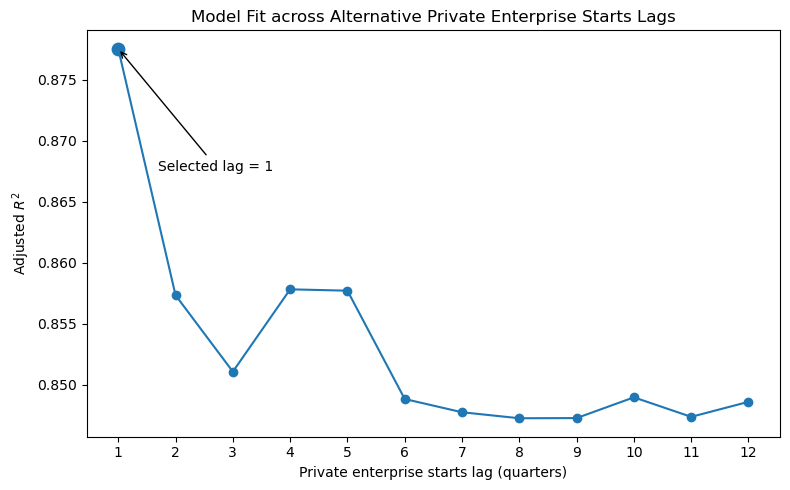


Starts-lag selection figure saved successfully.


In [36]:
# ============================================================
# Figure: Model Fit across Alternative Private Starts Lags
# Preferred Shock Specification
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path


# ============================================================
# 1. Create dataset for starts-lag comparison
# ============================================================

preferred_lag_df = df.copy()

preferred_lag_df = preferred_lag_df[
    (preferred_lag_df["starts_private"] > 0) &
    (preferred_lag_df["completions_private"] > 0)
].copy()


# Log variables
preferred_lag_df["ln_C_private"] = np.log(
    preferred_lag_df["completions_private"]
)

preferred_lag_df["ln_S_private"] = np.log(
    preferred_lag_df["starts_private"]
)


# Completion lags used during starts-lag selection
preferred_lag_df["ln_C_private_lag1"] = (
    preferred_lag_df["ln_C_private"].shift(1)
)

preferred_lag_df["ln_C_private_lag2"] = (
    preferred_lag_df["ln_C_private"].shift(2)
)


# Starts lags 1-12
for lag in range(1, 13):
    preferred_lag_df[f"ln_S_private_lag{lag}"] = (
        preferred_lag_df["ln_S_private"].shift(lag)
    )


# Quarterly seasonality
preferred_lag_df["quarter_num"] = (
    preferred_lag_df.index.quarter
)


# ============================================================
# 2. Preferred historical shock controls
# ============================================================

preferred_lag_df["gfc_2008_2009"] = (
    (preferred_lag_df.index >= pd.Period("2008Q3", freq="Q")) &
    (preferred_lag_df.index <= pd.Period("2009Q4", freq="Q"))
).astype(int)

preferred_lag_df["covid_2020Q2"] = (
    preferred_lag_df.index == pd.Period("2020Q2", freq="Q")
).astype(int)

preferred_lag_df["covid_2020Q3"] = (
    preferred_lag_df.index == pd.Period("2020Q3", freq="Q")
).astype(int)

preferred_lag_df["covid_2020Q4"] = (
    preferred_lag_df.index == pd.Period("2020Q4", freq="Q")
).astype(int)


# Common sample for all 12 models
preferred_lag_df = preferred_lag_df.dropna().copy()


# ============================================================
# 3. Compare starts lags 1-12
# ============================================================

preferred_lag_results = []

for lag in range(1, 13):

    formula = f"""
    ln_C_private ~ ln_C_private_lag1
    + ln_C_private_lag2
    + ln_S_private_lag{lag}
    + C(quarter_num)
    + gfc_2008_2009
    + covid_2020Q2
    + covid_2020Q3
    + covid_2020Q4
    """

    model = smf.ols(
        formula,
        data=preferred_lag_df
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 4}
    )

    preferred_lag_results.append({
        "Lag": lag,
        "Coefficient": model.params[f"ln_S_private_lag{lag}"],
        "P_value": model.pvalues[f"ln_S_private_lag{lag}"],
        "Adj_R_squared": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic
    })


preferred_lag_results = pd.DataFrame(
    preferred_lag_results
)


# ============================================================
# 4. Identify selected lag
# ============================================================

best_row = preferred_lag_results.loc[
    preferred_lag_results["Adj_R_squared"].idxmax()
]

best_lag = int(best_row["Lag"])
best_r2 = best_row["Adj_R_squared"]


print("==========================================")
print("PREFERRED STARTS-LAG SELECTION")
print("==========================================")

print(
    preferred_lag_results
    .round(6)
    .to_string(index=False)
)

print("\nSelected starts lag:", best_lag)
print("Adjusted R-squared:", best_r2)
print("P-value:", best_row["P_value"])


# ============================================================
# 5. Plot model fit
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    preferred_lag_results["Lag"],
    preferred_lag_results["Adj_R_squared"],
    marker="o"
)

plt.scatter(
    best_lag,
    best_r2,
    s=80
)

plt.annotate(
    f"Selected lag = {best_lag}",
    (best_lag, best_r2),
    xytext=(best_lag + 0.7, best_r2 - 0.01),
    arrowprops=dict(arrowstyle="->")
)

plt.title(
    "Model Fit across Alternative Private Enterprise Starts Lags"
)

plt.xlabel(
    "Private enterprise starts lag (quarters)"
)

plt.ylabel(
    "Adjusted $R^2$"
)

plt.xticks(range(1, 13))

plt.tight_layout()


# ============================================================
# 6. Save figure
# ============================================================

OUTPUT_DIR = Path(r"D:\data\outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.savefig(
    OUTPUT_DIR / "starts_lag_selection_adj_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nStarts-lag selection figure saved successfully.")

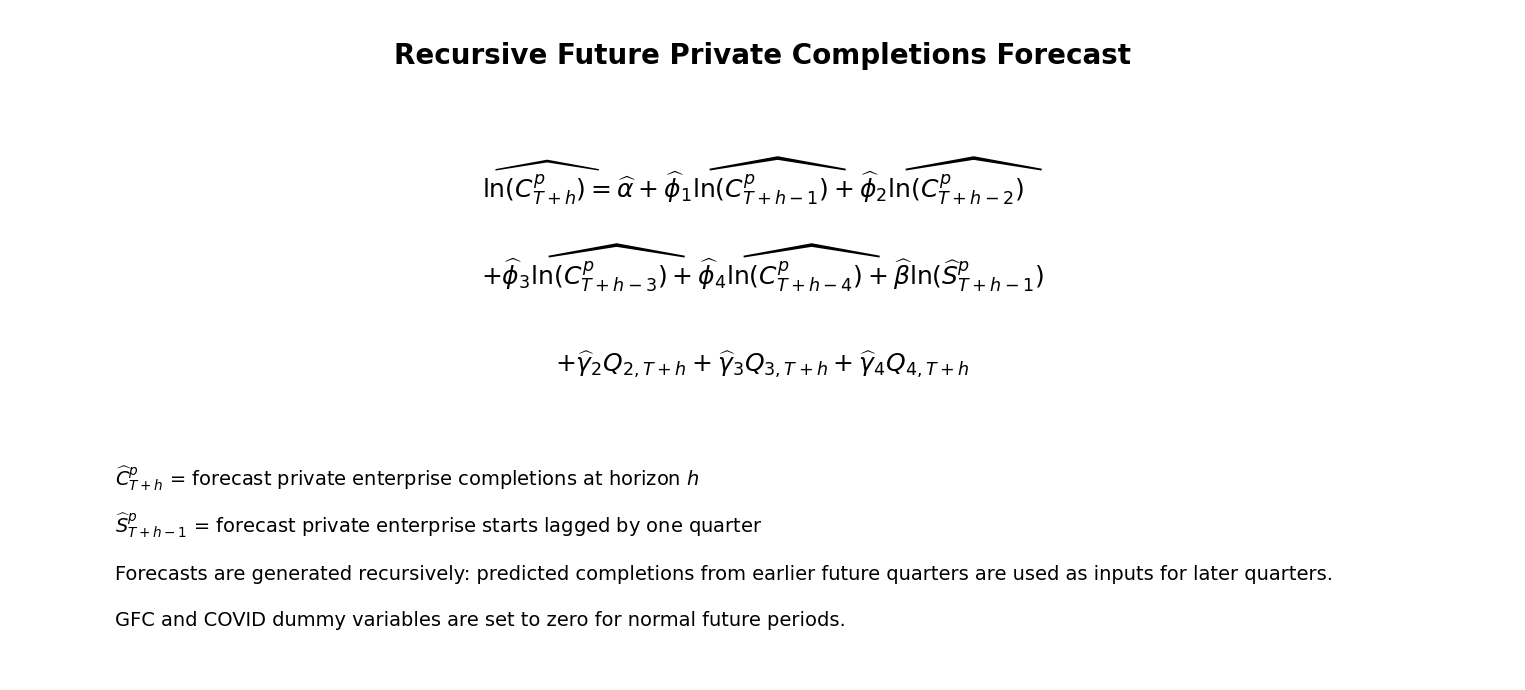

Future forecast equation figure saved successfully.


In [37]:
# ============================================================
# Future Private Completions Forecast Equation
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis("off")

# Title
ax.text(
    0.5,
    0.92,
    "Recursive Future Private Completions Forecast",
    fontsize=20,
    fontweight="bold",
    ha="center"
)

# Forecast equation - line 1
ax.text(
    0.5,
    0.72,
    r"$\widehat{\ln(C_{T+h}^{p})}"
    r" = \widehat{\alpha}"
    r" + \widehat{\phi}_1\widehat{\ln(C_{T+h-1}^{p})}"
    r" + \widehat{\phi}_2\widehat{\ln(C_{T+h-2}^{p})}$",
    fontsize=18,
    ha="center"
)

# Forecast equation - line 2
ax.text(
    0.5,
    0.59,
    r"$+ \widehat{\phi}_3\widehat{\ln(C_{T+h-3}^{p})}"
    r" + \widehat{\phi}_4\widehat{\ln(C_{T+h-4}^{p})}"
    r" + \widehat{\beta}\ln(\widehat{S}_{T+h-1}^{p})$",
    fontsize=18,
    ha="center"
)

# Forecast equation - line 3
ax.text(
    0.5,
    0.46,
    r"$+ \widehat{\gamma}_2Q_{2,T+h}"
    r" + \widehat{\gamma}_3Q_{3,T+h}"
    r" + \widehat{\gamma}_4Q_{4,T+h}$",
    fontsize=18,
    ha="center"
)

# Definitions
ax.text(
    0.07,
    0.29,
    r"$\widehat{C}_{T+h}^{p}$ = forecast private enterprise completions at horizon $h$",
    fontsize=14
)

ax.text(
    0.07,
    0.22,
    r"$\widehat{S}_{T+h-1}^{p}$ = forecast private enterprise starts lagged by one quarter",
    fontsize=14
)

ax.text(
    0.07,
    0.15,
    "Forecasts are generated recursively: predicted completions from earlier "
    "future quarters are used as inputs for later quarters.",
    fontsize=14
)

ax.text(
    0.07,
    0.08,
    "GFC and COVID dummy variables are set to zero for normal future periods.",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "future_private_completions_forecast_equation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Future forecast equation figure saved successfully.")

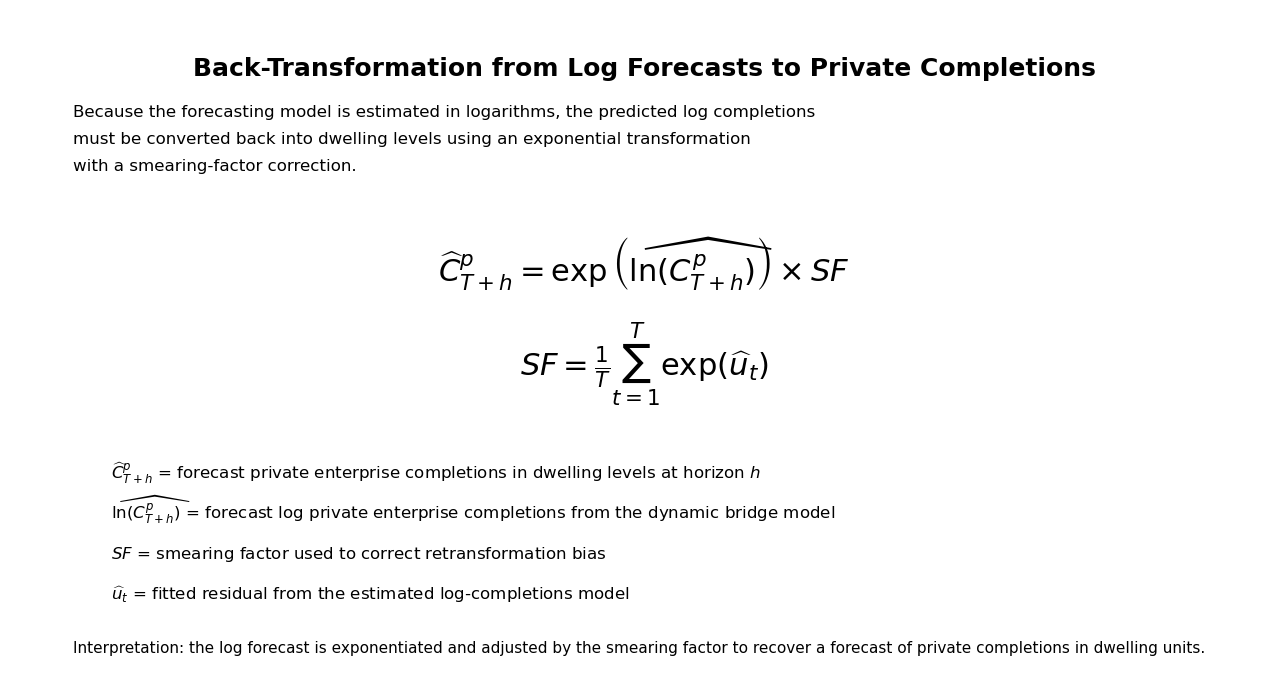

Back-transformation equation figure saved successfully.


In [38]:
import matplotlib.pyplot as plt

# If OUTPUT_DIR has not been created before, uncomment the next two lines:
# from pathlib import Path
# OUTPUT_DIR = Path(r"D:\data\outputs")

plt.figure(figsize=(14, 7))
plt.axis('off')

# Title
plt.text(
    0.5, 0.93,
    "Back-Transformation from Log Forecasts to Private Completions",
    ha='center', va='top',
    fontsize=18, fontweight='bold'
)

# Intro sentence
plt.text(
    0.05, 0.84,
    "Because the forecasting model is estimated in logarithms, the predicted log completions",
    fontsize=12
)
plt.text(
    0.05, 0.80,
    "must be converted back into dwelling levels using an exponential transformation",
    fontsize=12
)
plt.text(
    0.05, 0.76,
    "with a smearing-factor correction.",
    fontsize=12
)

# Equation 1
eq1 = (
    r"$\widehat{C}_{T+h}^{p}"
    r"="
    r"\exp\left(\widehat{\ln(C_{T+h}^{p})}\right)\times SF$"
)

plt.text(
    0.5, 0.62,
    eq1,
    ha='center', va='center',
    fontsize=22
)

# Equation 2
eq2 = (
    r"$SF=\frac{1}{T}\sum_{t=1}^{T}\exp(\widehat{u}_t)$"
)

plt.text(
    0.5, 0.47,
    eq2,
    ha='center', va='center',
    fontsize=22
)

# Definitions
plt.text(
    0.08, 0.30,
    r"$\widehat{C}_{T+h}^{p}$ = forecast private enterprise completions in dwelling levels at horizon $h$",
    fontsize=12
)
plt.text(
    0.08, 0.24,
    r"$\widehat{\ln(C_{T+h}^{p})}$ = forecast log private enterprise completions from the dynamic bridge model",
    fontsize=12
)
plt.text(
    0.08, 0.18,
    r"$SF$ = smearing factor used to correct retransformation bias",
    fontsize=12
)
plt.text(
    0.08, 0.12,
    r"$\widehat{u}_t$ = fitted residual from the estimated log-completions model",
    fontsize=12
)

# Short interpretation
plt.text(
    0.05, 0.04,
    "Interpretation: the log forecast is exponentiated and adjusted by the smearing factor "
    "to recover a forecast of private completions in dwelling units.",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "back_transformation_private_completions_equation.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Back-transformation equation figure saved successfully.")

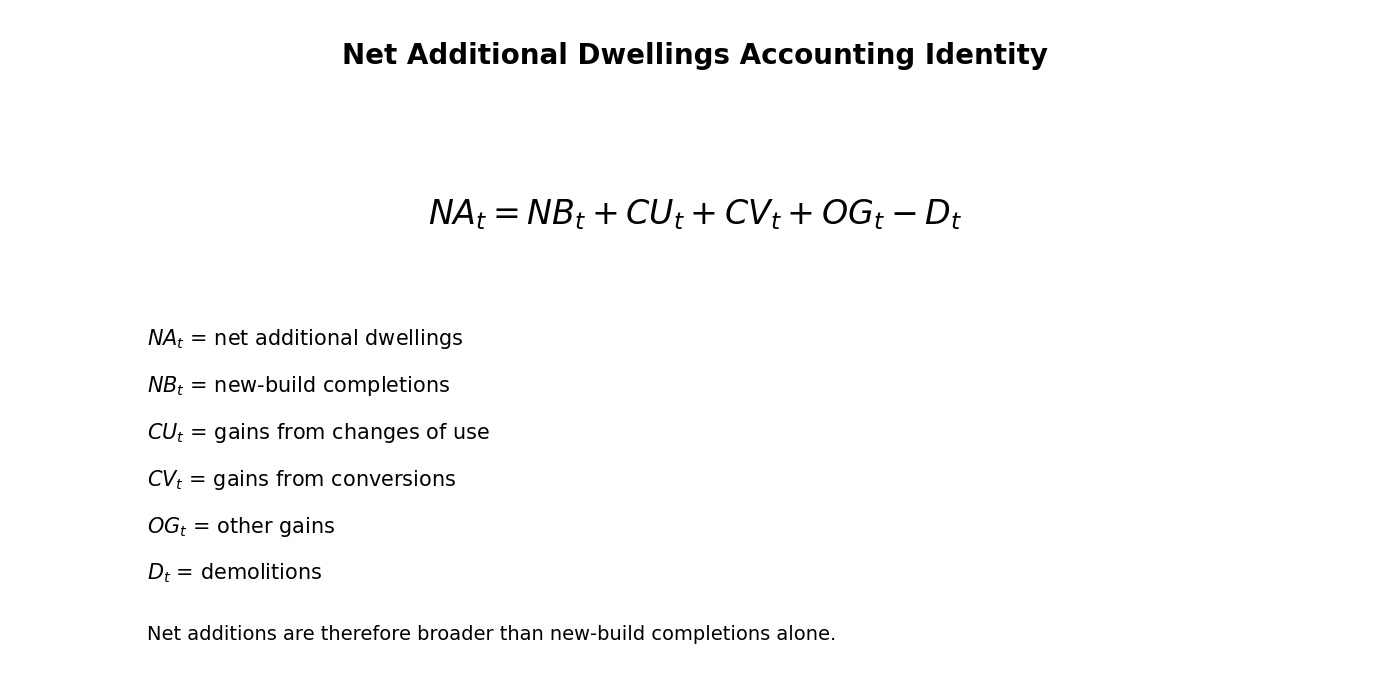

Net additions equation figure saved successfully.


In [39]:
# ============================================================
# Net Additional Dwellings Accounting Identity
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")

# Title
ax.text(
    0.5,
    0.92,
    "Net Additional Dwellings Accounting Identity",
    fontsize=20,
    fontweight="bold",
    ha="center"
)

# Main equation
ax.text(
    0.5,
    0.68,
    r"$NA_t = NB_t + CU_t + CV_t + OG_t - D_t$",
    fontsize=24,
    ha="center"
)

# Definitions
ax.text(
    0.10,
    0.50,
    r"$NA_t$ = net additional dwellings",
    fontsize=15
)

ax.text(
    0.10,
    0.43,
    r"$NB_t$ = new-build completions",
    fontsize=15
)

ax.text(
    0.10,
    0.36,
    r"$CU_t$ = gains from changes of use",
    fontsize=15
)

ax.text(
    0.10,
    0.29,
    r"$CV_t$ = gains from conversions",
    fontsize=15
)

ax.text(
    0.10,
    0.22,
    r"$OG_t$ = other gains",
    fontsize=15
)

ax.text(
    0.10,
    0.15,
    r"$D_t$ = demolitions",
    fontsize=15
)

# Interpretation
ax.text(
    0.10,
    0.06,
    "Net additions are therefore broader than new-build completions alone.",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "net_additional_dwellings_identity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Net additions equation figure saved successfully.")

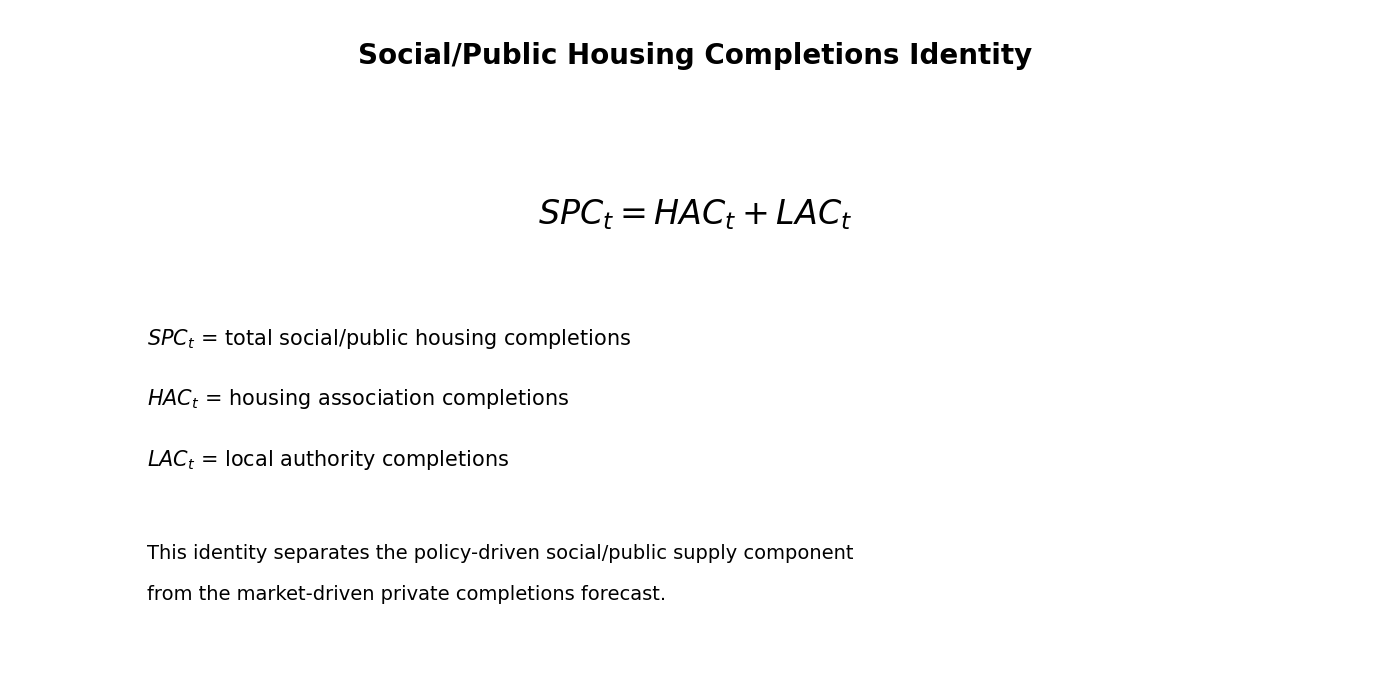

Social/public housing equation figure saved successfully.


In [40]:
# ============================================================
# Social/Public Housing Completions Identity
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")

# Title
ax.text(
    0.5,
    0.92,
    "Social/Public Housing Completions Identity",
    fontsize=20,
    fontweight="bold",
    ha="center"
)

# Main equation
ax.text(
    0.5,
    0.68,
    r"$SPC_t = HAC_t + LAC_t$",
    fontsize=24,
    ha="center"
)

# Definitions
ax.text(
    0.10,
    0.50,
    r"$SPC_t$ = total social/public housing completions",
    fontsize=15
)

ax.text(
    0.10,
    0.41,
    r"$HAC_t$ = housing association completions",
    fontsize=15
)

ax.text(
    0.10,
    0.32,
    r"$LAC_t$ = local authority completions",
    fontsize=15
)

# Interpretation
ax.text(
    0.10,
    0.18,
    "This identity separates the policy-driven social/public supply component",
    fontsize=14
)

ax.text(
    0.10,
    0.12,
    "from the market-driven private completions forecast.",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "social_public_housing_completions_identity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Social/public housing equation figure saved successfully.")

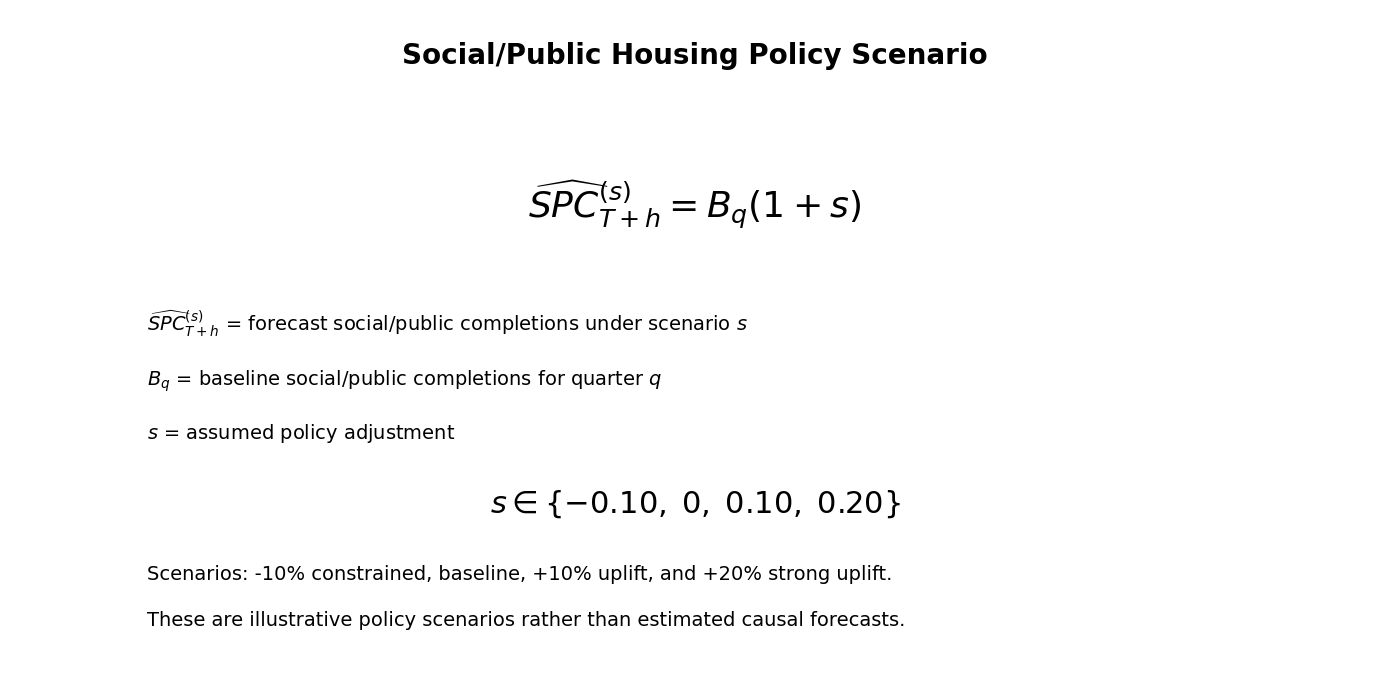

Social/public policy scenario figure saved successfully.


In [41]:
# ============================================================
# Social/Public Housing Policy Scenario
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")

# Title
ax.text(
    0.5,
    0.92,
    "Social/Public Housing Policy Scenario",
    fontsize=20,
    fontweight="bold",
    ha="center"
)

# Main equation
ax.text(
    0.5,
    0.69,
    r"$\widehat{SPC}_{T+h}^{(s)} = B_q(1+s)$",
    fontsize=26,
    ha="center"
)

# Definitions
ax.text(
    0.10,
    0.52,
    r"$\widehat{SPC}_{T+h}^{(s)}$ = forecast social/public completions under scenario $s$",
    fontsize=14
)

ax.text(
    0.10,
    0.44,
    r"$B_q$ = baseline social/public completions for quarter $q$",
    fontsize=14
)

ax.text(
    0.10,
    0.36,
    r"$s$ = assumed policy adjustment",
    fontsize=14
)

# Scenario values
ax.text(
    0.5,
    0.25,
    r"$s \in \{-0.10,\;0,\;0.10,\;0.20\}$",
    fontsize=22,
    ha="center"
)

ax.text(
    0.10,
    0.15,
    "Scenarios: -10% constrained, baseline, +10% uplift, and +20% strong uplift.",
    fontsize=14
)

ax.text(
    0.10,
    0.08,
    "These are illustrative policy scenarios rather than estimated causal forecasts.",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "social_public_policy_scenario_equation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Social/public policy scenario figure saved successfully.")

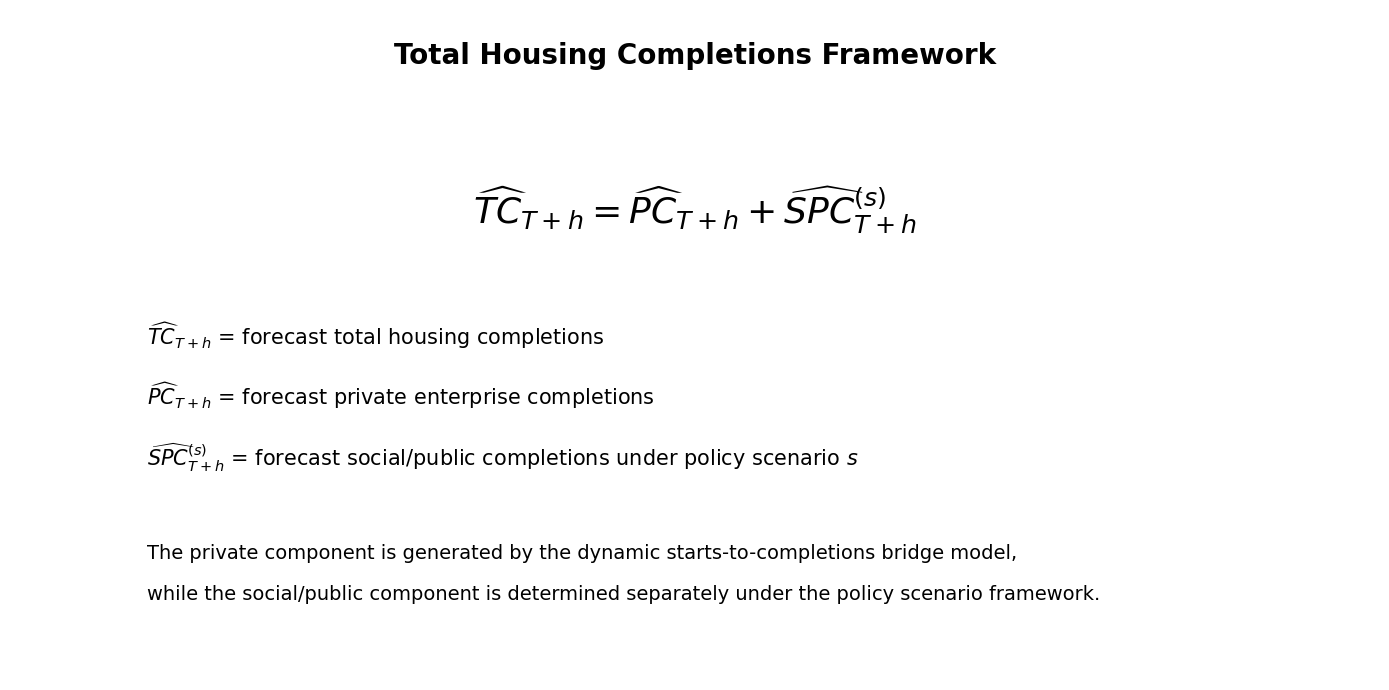

Total housing completions framework figure saved successfully.


In [42]:
# ============================================================
# Total Housing Completions Framework
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")

# Title
ax.text(
    0.5,
    0.92,
    "Total Housing Completions Framework",
    fontsize=20,
    fontweight="bold",
    ha="center"
)

# Main equation
ax.text(
    0.5,
    0.68,
    r"$\widehat{TC}_{T+h}"
    r"="
    r"\widehat{PC}_{T+h}"
    r"+"
    r"\widehat{SPC}_{T+h}^{(s)}$",
    fontsize=26,
    ha="center"
)

# Definitions
ax.text(
    0.10,
    0.50,
    r"$\widehat{TC}_{T+h}$ = forecast total housing completions",
    fontsize=15
)

ax.text(
    0.10,
    0.41,
    r"$\widehat{PC}_{T+h}$ = forecast private enterprise completions",
    fontsize=15
)

ax.text(
    0.10,
    0.32,
    r"$\widehat{SPC}_{T+h}^{(s)}$ = forecast social/public completions under policy scenario $s$",
    fontsize=15
)

# Interpretation
ax.text(
    0.10,
    0.18,
    "The private component is generated by the dynamic starts-to-completions bridge model,",
    fontsize=14
)

ax.text(
    0.10,
    0.12,
    "while the social/public component is determined separately under the policy scenario framework.",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "total_housing_completions_framework.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Total housing completions framework figure saved successfully.")

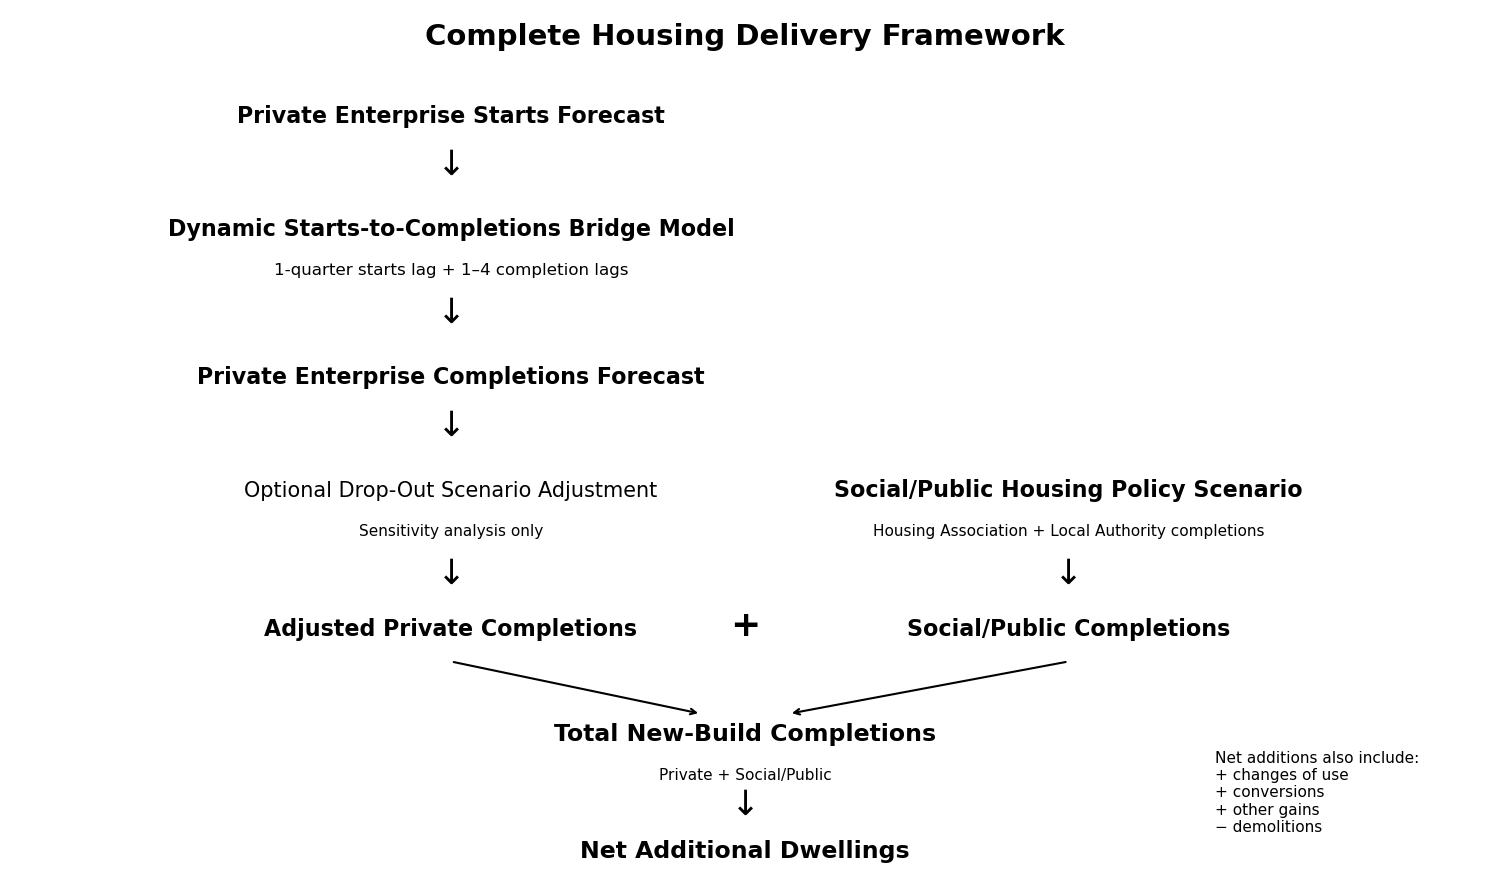

Complete housing delivery framework saved successfully.


In [43]:
# ============================================================
# Complete Housing Delivery Framework
# Final Preferred Framework
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. Output folder
# ============================================================

OUTPUT_DIR = Path(r"D:\data\outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# 2. Create figure
# ============================================================

fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")


# ============================================================
# Title
# ============================================================

ax.text(
    0.5,
    0.96,
    "Complete Housing Delivery Framework",
    fontsize=21,
    fontweight="bold",
    ha="center"
)


# ============================================================
# Private-sector forecasting pipeline
# ============================================================

ax.text(
    0.30,
    0.87,
    "Private Enterprise Starts Forecast",
    fontsize=16,
    fontweight="bold",
    ha="center"
)

ax.text(
    0.30,
    0.81,
    "↓",
    fontsize=25,
    ha="center"
)

ax.text(
    0.30,
    0.74,
    "Dynamic Starts-to-Completions Bridge Model",
    fontsize=16,
    fontweight="bold",
    ha="center"
)

ax.text(
    0.30,
    0.695,
    "1-quarter starts lag + 1–4 completion lags",
    fontsize=12,
    ha="center"
)

ax.text(
    0.30,
    0.64,
    "↓",
    fontsize=25,
    ha="center"
)

ax.text(
    0.30,
    0.57,
    "Private Enterprise Completions Forecast",
    fontsize=16,
    fontweight="bold",
    ha="center"
)


# ============================================================
# Optional drop-out sensitivity adjustment
# ============================================================

ax.text(
    0.30,
    0.51,
    "↓",
    fontsize=25,
    ha="center"
)

ax.text(
    0.30,
    0.44,
    "Optional Drop-Out Scenario Adjustment",
    fontsize=15,
    ha="center"
)

ax.text(
    0.30,
    0.395,
    "Sensitivity analysis only",
    fontsize=11,
    ha="center"
)

ax.text(
    0.30,
    0.34,
    "↓",
    fontsize=25,
    ha="center"
)

ax.text(
    0.30,
    0.28,
    "Adjusted Private Completions",
    fontsize=16,
    fontweight="bold",
    ha="center"
)


# ============================================================
# Social / public housing component
# ============================================================

ax.text(
    0.72,
    0.44,
    "Social/Public Housing Policy Scenario",
    fontsize=16,
    fontweight="bold",
    ha="center"
)

ax.text(
    0.72,
    0.395,
    "Housing Association + Local Authority completions",
    fontsize=11,
    ha="center"
)

ax.text(
    0.72,
    0.34,
    "↓",
    fontsize=25,
    ha="center"
)

ax.text(
    0.72,
    0.28,
    "Social/Public Completions",
    fontsize=16,
    fontweight="bold",
    ha="center"
)


# ============================================================
# Combine private and social/public completions
# ============================================================

ax.text(
    0.50,
    0.28,
    "+",
    fontsize=26,
    fontweight="bold",
    ha="center"
)


# Arrows from both components to total new-build completions
ax.annotate(
    "",
    xy=(0.47, 0.19),
    xytext=(0.30, 0.25),
    arrowprops=dict(arrowstyle="->", linewidth=1.5)
)

ax.annotate(
    "",
    xy=(0.53, 0.19),
    xytext=(0.72, 0.25),
    arrowprops=dict(arrowstyle="->", linewidth=1.5)
)


# ============================================================
# Total new-build completions
# ============================================================

ax.text(
    0.50,
    0.16,
    "Total New-Build Completions",
    fontsize=17,
    fontweight="bold",
    ha="center"
)

ax.text(
    0.50,
    0.115,
    "Private + Social/Public",
    fontsize=11,
    ha="center"
)

ax.text(
    0.50,
    0.075,
    "↓",
    fontsize=25,
    ha="center"
)


# ============================================================
# Net additions
# ============================================================

ax.text(
    0.50,
    0.025,
    "Net Additional Dwellings",
    fontsize=17,
    fontweight="bold",
    ha="center"
)

ax.text(
    0.82,
    0.10,
    "Net additions also include:\n"
    "+ changes of use\n"
    "+ conversions\n"
    "+ other gains\n"
    "− demolitions",
    fontsize=11,
    ha="left",
    va="center"
)


# ============================================================
# Save figure
# ============================================================

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "complete_housing_delivery_framework.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Complete housing delivery framework saved successfully.")

In [44]:
# ============================================================
# Benchmark Completion Forecast - Michalis (2023)
# Create Future Private Starts Scenarios
# ============================================================

import pandas as pd

michalis_starts = pd.DataFrame({
    "quarter": [
        "2025Q4",
        "2026Q1", "2026Q2", "2026Q3", "2026Q4",
        "2027Q1", "2027Q2", "2027Q3", "2027Q4",
        "2028Q1"
    ],
    "starts_low": [
        6933,
        7545, 8145, 7874, 6475,
        6554, 7694, 7946, 6189,
        6905
    ],
    "starts_mean": [
        12570,
        13554, 15151, 14271, 11594,
        12745, 14557, 13781, 11359,
        12612
    ],
    "starts_high": [
        21622,
        23708, 26428, 26206, 21147,
        23431, 26528, 25633, 20644,
        22565
    ]
})

michalis_starts["quarter"] = pd.PeriodIndex(
    michalis_starts["quarter"],
    freq="Q"
)

michalis_starts = michalis_starts.set_index("quarter")

display(michalis_starts)

,starts_low,starts_mean,starts_high
quarter,,,
2025Q4,6933,12570,21622
2026Q1,7545,13554,23708
2026Q2,8145,15151,26428
2026Q3,7874,14271,26206
2026Q4,6475,11594,21147
2027Q1,6554,12745,23431
2027Q2,7694,14557,26528
2027Q3,7946,13781,25633
2027Q4,6189,11359,20644


In [45]:
# ============================================================
# Benchmark Completion Forecast - Michalis (2023)
# Check Final Bridge Model and Historical Inputs
# ============================================================

import numpy as np
import pandas as pd

print("==========================================")
print("FINAL BRIDGE MODEL CHECK")
print("==========================================")

print("Starts coefficient:",
      preferred_model.params["ln_S_private_lag1"])

print("Completion lag coefficients:")
print("lag 1 =", preferred_model.params["ln_C_private_lag1"])
print("lag 2 =", preferred_model.params["ln_C_private_lag2"])
print("lag 3 =", preferred_model.params["ln_C_private_lag3"])
print("lag 4 =", preferred_model.params["ln_C_private_lag4"])

print("\nSmearing factor:", smearing_factor)

print("\n==========================================")
print("LAST 4 OBSERVED PRIVATE COMPLETIONS")
print("==========================================")

last4 = completion_df[[
    "actual_C_private",
    "ln_C_private"
]].dropna().tail(4)

display(last4)

FINAL BRIDGE MODEL CHECK
Starts coefficient: 0.2159005773419365
Completion lag coefficients:
lag 1 = 0.21162400017134764
lag 2 = 0.39203686523706666
lag 3 = -0.032242172744269715
lag 4 = 0.15550081464465015

Smearing factor: 1.002273597136804

LAST 4 OBSERVED PRIVATE COMPLETIONS


,actual_C_private,ln_C_private
quarter,,
2025Q1,23690.0,10.072808
2025Q2,27900.0,10.236382
2025Q3,23120.0,10.048453
2025Q4,29700.0,10.298902


In [46]:
# ============================================================
# Benchmark Completion Forecast - Michalis (2023)
# Recursive Private Completions Forecast
# Low / Mean / High Starts Scenarios
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. Function for recursive completion forecasting
# ============================================================

def recursive_completion_forecast(starts_column):

    historical_logs = (
        completion_df["ln_C_private"]
        .dropna()
        .tail(4)
        .tolist()
    )

    completion_history = historical_logs.copy()

    forecast_rows = []

    starts_series = michalis_starts[starts_column]

    for starts_quarter, starts_value in starts_series.items():

        forecast_quarter = starts_quarter + 1

        lag1 = completion_history[-1]
        lag2 = completion_history[-2]
        lag3 = completion_history[-3]
        lag4 = completion_history[-4]

        quarter_num = forecast_quarter.quarter

        new_data = pd.DataFrame({
            "ln_C_private_lag1": [lag1],
            "ln_C_private_lag2": [lag2],
            "ln_C_private_lag3": [lag3],
            "ln_C_private_lag4": [lag4],
            "ln_S_private_lag1": [np.log(starts_value)],
            "quarter_num": [quarter_num],
            "gfc_2008_2009": [0],
            "covid_2020Q2": [0],
            "covid_2020Q3": [0],
            "covid_2020Q4": [0]
        })

        forecast_log = float(
            preferred_model.predict(new_data).iloc[0]
        )

        forecast_level = (
            np.exp(forecast_log) * smearing_factor
        )

        forecast_rows.append({
            "quarter": forecast_quarter,
            "starts": starts_value,
            "forecast_ln_completion": forecast_log,
            "forecast_completion": forecast_level
        })

        completion_history.append(forecast_log)

    return pd.DataFrame(forecast_rows).set_index("quarter")


# ============================================================
# 2. Run all three Michalis scenarios
# ============================================================

forecast_low = recursive_completion_forecast("starts_low")
forecast_mean = recursive_completion_forecast("starts_mean")
forecast_high = recursive_completion_forecast("starts_high")


# ============================================================
# 3. Combine completion forecasts
# ============================================================

michalis_completion_forecast = pd.DataFrame({
    "starts_low": forecast_low["starts"],
    "completion_low": forecast_low["forecast_completion"],

    "starts_mean": forecast_mean["starts"],
    "completion_mean": forecast_mean["forecast_completion"],

    "starts_high": forecast_high["starts"],
    "completion_high": forecast_high["forecast_completion"]
})


# Round dwelling forecasts for readability
display(
    michalis_completion_forecast.round(0).astype(int)
)

,starts_low,completion_low,starts_mean,completion_mean,starts_high,completion_high
quarter,,,,,,
2026Q1,6933,18368,12570,20886,21622,23481
2026Q2,7545,19804,13554,23093,23708,26710
2026Q3,8145,16114,15151,20017,26428,24371
2026Q4,7874,18277,14271,23012,26206,28851
2027Q1,6475,13755,11594,18102,21147,23672
2027Q2,6554,14312,12745,19493,23431,26133
2027Q3,7694,12738,14557,17842,26528,24573
2027Q4,7946,14353,13781,20131,25633,28373
2028Q1,6189,11403,11359,16467,20644,23588


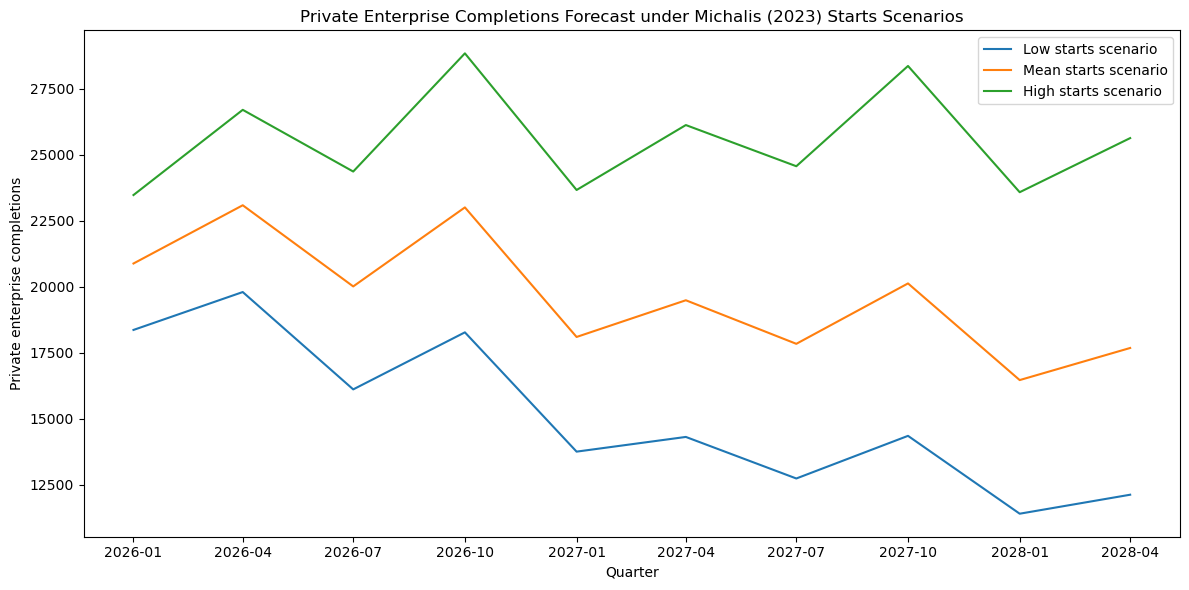

In [47]:
# ============================================================
# Benchmark Completion Forecast - Michalis (2023)
# Plot Low / Mean / High Completion Forecasts
# ============================================================

import matplotlib.pyplot as plt

plot_df = michalis_completion_forecast.copy()

plot_dates = plot_df.index.to_timestamp()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_dates,
    plot_df["completion_low"],
    label="Low starts scenario"
)

plt.plot(
    plot_dates,
    plot_df["completion_mean"],
    label="Mean starts scenario"
)

plt.plot(
    plot_dates,
    plot_df["completion_high"],
    label="High starts scenario"
)

plt.title(
    "Private Enterprise Completions Forecast "
    "under Michalis (2023) Starts Scenarios"
)

plt.xlabel("Quarter")
plt.ylabel("Private enterprise completions")

plt.legend()
plt.tight_layout()

plt.show()

In [48]:
# ============================================================
# Benchmark Completion Forecast - Michalis (2023)
# Annual and Cumulative Completion Totals
# ============================================================

summary_df = michalis_completion_forecast[
    ["completion_low", "completion_mean", "completion_high"]
].copy()

# Add calendar year
summary_df["year"] = summary_df.index.year

# ============================================================
# 1. Annual totals
# ============================================================

annual_completion_totals = (
    summary_df
    .groupby("year")[
        ["completion_low", "completion_mean", "completion_high"]
    ]
    .sum()
)

annual_completion_totals.columns = [
    "Low scenario",
    "Mean scenario",
    "High scenario"
]

print("==========================================")
print("ANNUAL PRIVATE ENTERPRISE COMPLETIONS")
print("==========================================")

display(
    annual_completion_totals.round(0).astype(int)
)


# ============================================================
# 2. Cumulative totals across full forecast horizon
# ============================================================

cumulative_completion_totals = pd.DataFrame({
    "Scenario": [
        "Low",
        "Mean",
        "High"
    ],
    "Cumulative_private_completions": [
        summary_df["completion_low"].sum(),
        summary_df["completion_mean"].sum(),
        summary_df["completion_high"].sum()
    ]
})

cumulative_completion_totals[
    "Cumulative_private_completions"
] = (
    cumulative_completion_totals[
        "Cumulative_private_completions"
    ]
    .round(0)
    .astype(int)
)

print("\n==========================================")
print("CUMULATIVE PRIVATE ENTERPRISE COMPLETIONS")
print("==========================================")

display(cumulative_completion_totals)

ANNUAL PRIVATE ENTERPRISE COMPLETIONS


,Low scenario,Mean scenario,High scenario
year,,,
2026,72563,87009,103414
2027,55159,75567,102751
2028,23525,34151,49227



CUMULATIVE PRIVATE ENTERPRISE COMPLETIONS


,Scenario,Cumulative_private_completions
0,Low,151247
1,Mean,196727
2,High,255392


In [49]:
# ============================================================
# Group Completion Forecasts
# Create ARDL / NARDL Quarterly Starts Forecasts
# ============================================================

import pandas as pd

group_starts = pd.DataFrame({
    "quarter": [
        "2026Q1","2026Q2","2026Q3","2026Q4",
        "2027Q1","2027Q2","2027Q3","2027Q4",
        "2028Q1","2028Q2","2028Q3","2028Q4",
        "2029Q1","2029Q2","2029Q3","2029Q4",
        "2030Q1","2030Q2","2030Q3","2030Q4",
        "2031Q1"
    ],

    "ardl_starts": [
        22203.1608023023,
        22927.4340860882,
        21057.9477114311,
        18231.2830821964,
        20741.4643721492,
        21584.1766168054,
        20684.7477802377,
        17203.6270776536,
        20188.335758295,
        21193.9839278766,
        20598.7415551111,
        17114.6048863652,
        20108.3207955004,
        21250.4043382173,
        20668.9651140471,
        17254.8299690154,
        20332.9835598943,
        21598.2065412656,
        21024.6366914824,
        17493.4002448711,
        20555.9615752358
    ],

    "nardl_starts": [
        22164.7612981501,
        22810.9752199009,
        20162.1101239105,
        17461.6866771754,
        19231.9368635639,
        19865.6637496493,
        18243.854372477,
        15728.5043053257,
        18813.6192029246,
        19552.7345651948,
        19021.074975577,
        16065.1229218118,
        19324.6948189757,
        19861.1204256323,
        19600.1250407999,
        16422.1281954016,
        19687.3099656194,
        20363.0314810244,
        19980.738507011,
        16719.8714572376,
        19952.2047795571
    ]
})

group_starts["quarter"] = pd.PeriodIndex(
    group_starts["quarter"],
    freq="Q"
)

group_starts = group_starts.set_index("quarter")

display(group_starts)

,ardl_starts,nardl_starts
quarter,,
2026Q1,22203.160802,22164.761298
2026Q2,22927.434086,22810.975220
2026Q3,21057.947711,20162.110124
2026Q4,18231.283082,17461.686677
2027Q1,20741.464372,19231.936864
2027Q2,21584.176617,19865.663750
2027Q3,20684.747780,18243.854372
2027Q4,17203.627078,15728.504305
2028Q1,20188.335758,18813.619203


In [51]:
# ============================================================
# Group Completion Forecasts
# Recursive ARDL / NARDL Private Completions Forecast
# ============================================================

import numpy as np
import pandas as pd


def recursive_group_completion_forecast(starts_series):

    # Last four observed log private completions
    completion_history = (
        completion_df["ln_C_private"]
        .dropna()
        .tail(4)
        .tolist()
    )

    forecast_rows = []

    # Important:
    # group_starts begins at 2026Q1.
    # With a 1-quarter starts lag, 2026Q1 starts predict 2026Q2 completions.
    for starts_quarter, starts_value in starts_series.items():

        forecast_quarter = starts_quarter + 1

        lag1 = completion_history[-1]
        lag2 = completion_history[-2]
        lag3 = completion_history[-3]
        lag4 = completion_history[-4]

        new_data = pd.DataFrame({
            "ln_C_private_lag1": [lag1],
            "ln_C_private_lag2": [lag2],
            "ln_C_private_lag3": [lag3],
            "ln_C_private_lag4": [lag4],
            "ln_S_private_lag1": [np.log(starts_value)],
            "quarter_num": [forecast_quarter.quarter],

            "gfc_2008_2009": [0],
            "covid_2020Q2": [0],
            "covid_2020Q3": [0],
            "covid_2020Q4": [0]
        })

        forecast_log = float(
            preferred_model.predict(new_data).iloc[0]
        )

        forecast_level = (
            np.exp(forecast_log) * smearing_factor
        )

        forecast_rows.append({
            "quarter": forecast_quarter,
            "starts": starts_value,
            "forecast_ln_completion": forecast_log,
            "forecast_completion": forecast_level
        })

        completion_history.append(forecast_log)

    return pd.DataFrame(forecast_rows).set_index("quarter")


# ============================================================
# Run ARDL and NARDL starts paths through the same bridge
# ============================================================

ardl_completion = recursive_group_completion_forecast(
    group_starts["ardl_starts"]
)

nardl_completion = recursive_group_completion_forecast(
    group_starts["nardl_starts"]
)


# ============================================================
# Combine results
# ============================================================

group_completion_forecast = pd.DataFrame({
    "ardl_starts": ardl_completion["starts"],
    "ardl_completion": ardl_completion["forecast_completion"],

    "nardl_starts": nardl_completion["starts"],
    "nardl_completion": nardl_completion["forecast_completion"]
})

display(
    group_completion_forecast.round(0).astype(int)
)

,ardl_starts,ardl_completion,nardl_starts,nardl_completion
quarter,,,,
2026Q2,22203,24323,22165,24314
2026Q3,22927,26396,22811,26365
2026Q4,21058,25752,20162,25501
2027Q1,18231,24033,17462,23750
2027Q2,20741,24008,19232,23470
2027Q3,21584,23598,19866,22964
2027Q4,20685,25512,18244,24441
2028Q1,17204,21936,15729,21071
2028Q2,20188,23363,18814,22376


In [52]:
# ============================================================
# Group Completion Forecasts
# Fix: Check 2025Q4 Historical Private Starts
# ============================================================

seed_starts_2025Q4 = completion_df.loc[
    pd.Period("2025Q4", freq="Q"),
    "starts_private"
]

print("2025Q4 actual private enterprise starts:")
print(seed_starts_2025Q4)

2025Q4 actual private enterprise starts:
25380


In [53]:
# ============================================================
# Group Completion Forecasts
#(Corrected):
# Recursive ARDL / NARDL Private Completions Forecast
# Seeded with 2025Q4 actual private starts
# ============================================================

import numpy as np
import pandas as pd


def recursive_group_completion_forecast(starts_series, seed_starts):

    # 2025Q1, 2025Q2, 2025Q3, 2025Q4
    completion_history = (
        completion_df["ln_C_private"]
        .dropna()
        .tail(4)
        .tolist()
    )

    starts_extended = pd.concat([
        pd.Series(
            [seed_starts],
            index=pd.PeriodIndex(["2025Q4"], freq="Q")
        ),
        starts_series
    ])

    forecast_rows = []

    for starts_quarter, starts_value in starts_extended.items():


        forecast_quarter = starts_quarter + 1

        lag1 = completion_history[-1]
        lag2 = completion_history[-2]
        lag3 = completion_history[-3]
        lag4 = completion_history[-4]

        new_data = pd.DataFrame({
            "ln_C_private_lag1": [lag1],
            "ln_C_private_lag2": [lag2],
            "ln_C_private_lag3": [lag3],
            "ln_C_private_lag4": [lag4],
            "ln_S_private_lag1": [np.log(starts_value)],
            "quarter_num": [forecast_quarter.quarter],

            "gfc_2008_2009": [0],
            "covid_2020Q2": [0],
            "covid_2020Q3": [0],
            "covid_2020Q4": [0]
        })

        forecast_log = float(
            preferred_model.predict(new_data).iloc[0]
        )

        forecast_level = (
            np.exp(forecast_log) * smearing_factor
        )

        forecast_rows.append({
            "quarter": forecast_quarter,
            "starts_used": starts_value,
            "forecast_ln_completion": forecast_log,
            "forecast_completion": forecast_level
        })

        completion_history.append(forecast_log)

    return pd.DataFrame(forecast_rows).set_index("quarter")


# ============================================================
# Run ARDL and NARDL paths
# ============================================================

ardl_completion = recursive_group_completion_forecast(
    group_starts["ardl_starts"],
    seed_starts_2025Q4
)

nardl_completion = recursive_group_completion_forecast(
    group_starts["nardl_starts"],
    seed_starts_2025Q4
)


# ============================================================
# Combine results
# ============================================================

group_completion_forecast = pd.DataFrame({
    "ardl_starts_used": ardl_completion["starts_used"],
    "ardl_completion": ardl_completion["forecast_completion"],

    "nardl_starts_used": nardl_completion["starts_used"],
    "nardl_completion": nardl_completion["forecast_completion"]
})


display(
    group_completion_forecast.round(0).astype(int)
)

,ardl_starts_used,ardl_completion,nardl_starts_used,nardl_completion
quarter,,,,
2026Q1,25380,24307,25380,24307
2026Q2,22203,26528,22165,26518
2026Q3,22927,23923,22811,23895
2026Q4,21058,27309,20162,27043
2027Q1,18231,22623,17462,22357
2027Q2,20741,24663,19232,24110
2027Q3,21584,22782,19866,22170
2027Q4,20685,25876,18244,24790
2028Q1,17204,21478,15729,20632


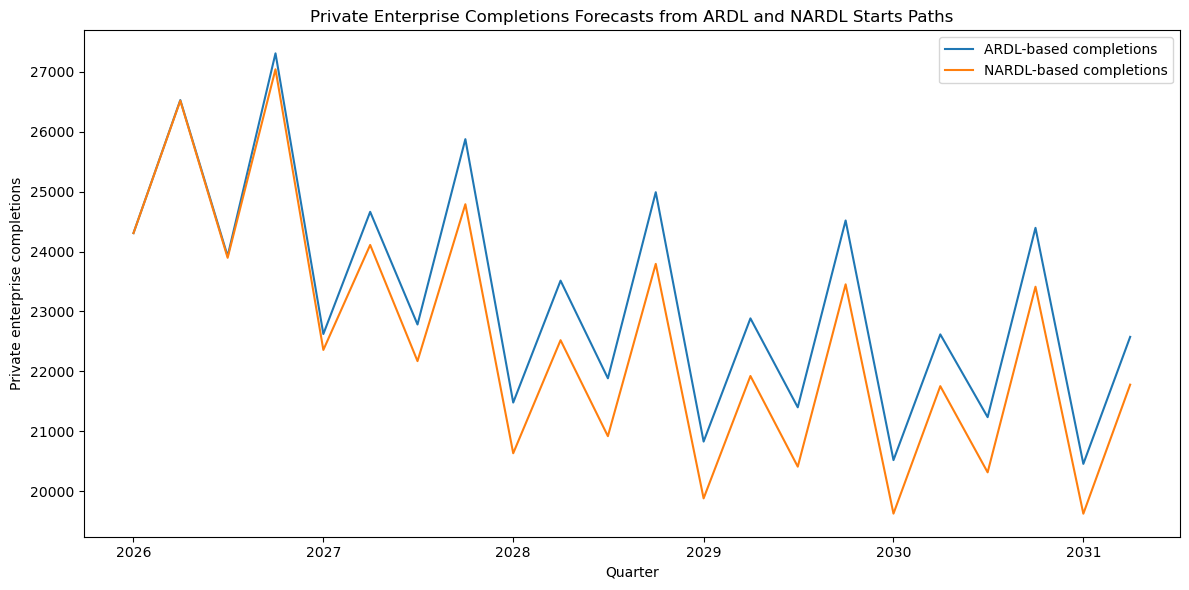

In [54]:
# ============================================================
# Group Completion Forecasts
# Plot ARDL vs NARDL Completion Forecasts
# ============================================================

import matplotlib.pyplot as plt

plot_dates = group_completion_forecast.index.to_timestamp()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_dates,
    group_completion_forecast["ardl_completion"],
    label="ARDL-based completions"
)

plt.plot(
    plot_dates,
    group_completion_forecast["nardl_completion"],
    label="NARDL-based completions"
)

plt.title(
    "Private Enterprise Completions Forecasts "
    "from ARDL and NARDL Starts Paths"
)

plt.xlabel("Quarter")
plt.ylabel("Private enterprise completions")

plt.legend()
plt.tight_layout()

plt.show()

In [55]:
# ============================================================
# Group Completion Forecasts
# Create VECM Quarterly Starts Forecast
# ============================================================

vecm_starts = pd.Series(
    [
        23252.029304932,
        27101.9162965427,
        23021.3260546515,
        20618.388049028,
        20544.7494306517,
        25086.922497891,
        23326.5757315971,
        20879.1758510088,
        22278.9194659192,
        26480.4460945154,
        24929.9925261809,
        21609.4380040406,
        23428.3987269349,
        27209.2703245071,
        25818.4974891069,
        22014.1718791594,
        24145.9134002831,
        27682.9078657147,
        26411.8372324927,
        22282.4428091748,
        24612.8800965261
    ],
    index=pd.PeriodIndex(
        [
            "2026Q1","2026Q2","2026Q3","2026Q4",
            "2027Q1","2027Q2","2027Q3","2027Q4",
            "2028Q1","2028Q2","2028Q3","2028Q4",
            "2029Q1","2029Q2","2029Q3","2029Q4",
            "2030Q1","2030Q2","2030Q3","2030Q4",
            "2031Q1"
        ],
        freq="Q"
    ),
    name="vecm_starts"
)

display(vecm_starts.to_frame())

,vecm_starts
2026Q1,23252.029305
2026Q2,27101.916297
2026Q3,23021.326055
2026Q4,20618.388049
2027Q1,20544.749431
2027Q2,25086.922498
2027Q3,23326.575732
2027Q4,20879.175851
2028Q1,22278.919466
2028Q2,26480.446095


In [56]:
# ============================================================
# Group Completion Forecasts
# VECM Completion Forecast
# and Combined ARDL / NARDL / VECM Results
# ============================================================

# Run VECM starts path through the same corrected bridge
vecm_completion = recursive_group_completion_forecast(
    vecm_starts,
    seed_starts_2025Q4
)

# Combine the three completion forecasts
group_completion_all = pd.DataFrame({
    "ardl_completion": ardl_completion["forecast_completion"],
    "nardl_completion": nardl_completion["forecast_completion"],
    "vecm_completion": vecm_completion["forecast_completion"]
})

print("==========================================")
print("GROUP PRIVATE ENTERPRISE COMPLETION FORECASTS")
print("==========================================")

display(
    group_completion_all.round(0).astype(int)
)

GROUP PRIVATE ENTERPRISE COMPLETION FORECASTS


,ardl_completion,nardl_completion,vecm_completion
quarter,,,
2026Q1,24307,24307,24307
2026Q2,26528,26518,26794
2026Q3,23923,23895,24855
2026Q4,27309,27043,28175
2027Q1,22623,22357,23731
2027Q2,24663,24110,25177
2027Q3,22782,22170,24203
2027Q4,25876,24790,27207
2028Q1,21478,20632,23335


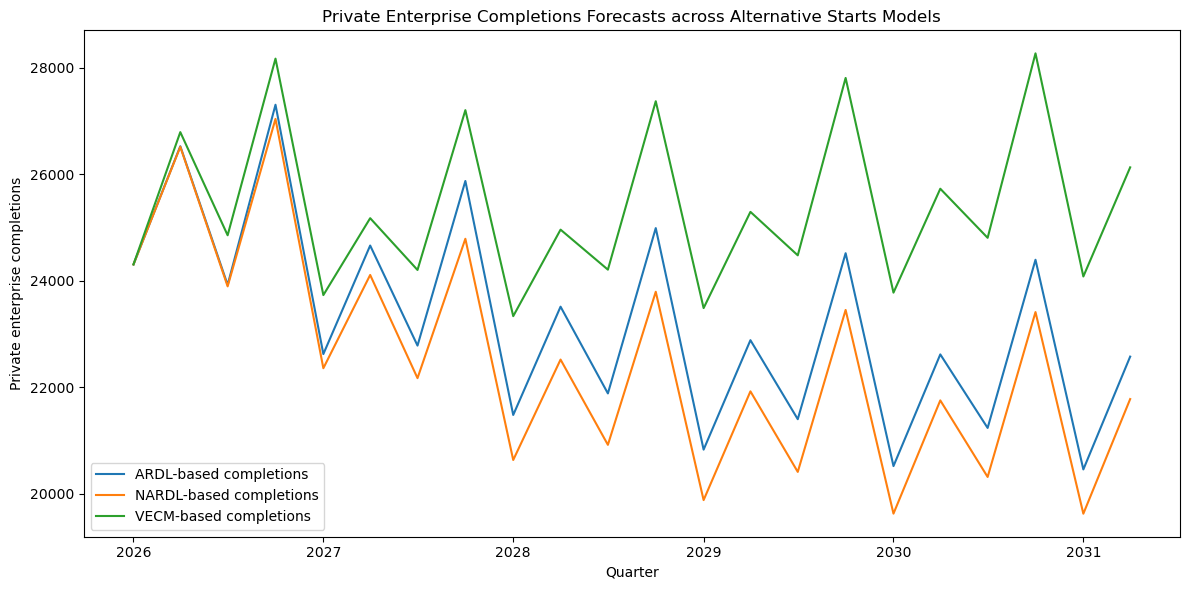

In [57]:
# ============================================================
# Group Completion Forecasts
# Plot ARDL / NARDL / VECM Completion Forecasts
# ============================================================

import matplotlib.pyplot as plt

plot_dates = group_completion_all.index.to_timestamp()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_dates,
    group_completion_all["ardl_completion"],
    label="ARDL-based completions"
)

plt.plot(
    plot_dates,
    group_completion_all["nardl_completion"],
    label="NARDL-based completions"
)

plt.plot(
    plot_dates,
    group_completion_all["vecm_completion"],
    label="VECM-based completions"
)

plt.title(
    "Private Enterprise Completions Forecasts "
    "across Alternative Starts Models"
)

plt.xlabel("Quarter")
plt.ylabel("Private enterprise completions")

plt.legend()
plt.tight_layout()

plt.show()

In [58]:
# ============================================================
# Group Completion Forecasts
# Annual and Cumulative Completion Totals
# ARDL / NARDL / VECM
# ============================================================

summary_group = group_completion_all.copy()

summary_group["year"] = summary_group.index.year


# ============================================================
# 1. Annual private enterprise completions
# ============================================================

annual_group_completions = (
    summary_group
    .groupby("year")[
        [
            "ardl_completion",
            "nardl_completion",
            "vecm_completion"
        ]
    ]
    .sum()
)

annual_group_completions.columns = [
    "ARDL",
    "NARDL",
    "VECM"
]

print("==========================================")
print("ANNUAL PRIVATE ENTERPRISE COMPLETIONS")
print("==========================================")

display(
    annual_group_completions.round(0).astype(int)
)


# ============================================================
# 2. Cumulative private enterprise completions
# ============================================================

cumulative_group_completions = pd.DataFrame({
    "Model": [
        "ARDL",
        "NARDL",
        "VECM"
    ],

    "Cumulative_private_completions": [
        group_completion_all["ardl_completion"].sum(),
        group_completion_all["nardl_completion"].sum(),
        group_completion_all["vecm_completion"].sum()
    ]
})

cumulative_group_completions[
    "Cumulative_private_completions"
] = (
    cumulative_group_completions[
        "Cumulative_private_completions"
    ]
    .round(0)
    .astype(int)
)

print("\n==========================================")
print("CUMULATIVE PRIVATE ENTERPRISE COMPLETIONS")
print("==========================================")

display(cumulative_group_completions)

ANNUAL PRIVATE ENTERPRISE COMPLETIONS


,ARDL,NARDL,VECM
year,,,
2026,102068,101764,104132
2027,95943,93426,100319
2028,91865,87862,99881
2029,89628,85660,101073
2030,88764,85101,102589
2031,43029,41400,50213



CUMULATIVE PRIVATE ENTERPRISE COMPLETIONS


,Model,Cumulative_private_completions
0,ARDL,511297
1,NARDL,495213
2,VECM,558207


In [59]:
# ============================================================
# Social/Public Housing Component
# Check Available Completion Series
# ============================================================

print("==========================================")
print("AVAILABLE COLUMNS IN completion_df")
print("==========================================")

for col in completion_df.columns:
    if (
        "completion" in col.lower()
        or "housing" in col.lower()
        or "authority" in col.lower()
        or "association" in col.lower()
        or "private" in col.lower()
    ):
        print(col)


print("\n==========================================")
print("MOST RECENT OBSERVATIONS")
print("==========================================")

display(
    completion_df.tail(12)
)

AVAILABLE COLUMNS IN completion_df
completions_all
starts_private
completions_private
ln_C_private
ln_S_private
ln_C_private_lag1
ln_C_private_lag2
ln_C_private_lag3
ln_C_private_lag4
ln_S_private_lag1
fitted_ln_C_private
fitted_C_private
actual_C_private

MOST RECENT OBSERVATIONS


,period,starts_all,completions_all,starts_private,completions_private,ln_C_private,ln_S_private,ln_C_private_lag1,ln_C_private_lag2,ln_C_private_lag3,...,ln_S_private_lag1,quarter_num,gfc_2008_2009,covid_2020Q2,covid_2020Q3,covid_2020Q4,fitted_ln_C_private,fitted_C_private,actual_C_private,date
quarter,,,,,,,,,,,,,,,,,,,,,
2023Q1,Jan - Mar 2023,38630,37300,28840,27790,10.232432,10.269519,10.622302,10.399707,10.541650,...,10.121820,1,0,0,0,0,10.340566,31033.945542,27790.0,2023-01-01
2023Q2,Apr - Jun 2023,72980,40730,53690,31380,10.353926,10.890982,10.232432,10.622302,10.399707,...,10.269519,2,0,0,0,0,10.431906,34002.086404,31380.0,2023-04-01
2023Q3,Jul - Sep 2023,21990,40470,17530,32500,10.388995,9.771669,10.353926,10.232432,10.622302,...,10.890982,3,0,0,0,0,10.397643,32856.805566,32500.0,2023-07-01
2023Q4,Oct - Dec 2023,17000,44770,12800,33310,10.413613,9.457200,10.388995,10.353926,10.232432,...,9.771669,4,0,0,0,0,10.351054,31361.143951,33310.0,2023-10-01
2024Q1,Jan - Mar 2024,24480,34360,17100,24970,10.125430,9.746834,10.413613,10.388995,10.353926,...,9.457200,1,0,0,0,0,10.127292,25073.399575,24970.0,2024-01-01
2024Q2,Apr - Jun 2024,27340,44630,18690,34720,10.455071,9.835744,10.125430,10.413613,10.388995,...,9.746834,2,0,0,0,0,10.185754,26582.948900,34720.0,2024-04-01
2024Q3,Jul - Sep 2024,30750,34000,21440,26100,10.169691,9.973014,10.455071,10.125430,10.413613,...,9.835744,3,0,0,0,0,10.154336,25760.740625,26100.0,2024-07-01
2024Q4,Oct - Dec 2024,25570,40850,18780,29910,10.305948,9.840548,10.169691,10.455071,10.125430,...,9.973014,4,0,0,0,0,10.358765,31603.918673,29910.0,2024-10-01
2025Q1,Jan - Mar 2025,29220,32560,21960,23690,10.072808,9.996978,10.305948,10.169691,10.455071,...,9.840548,1,0,0,0,0,10.081397,23948.663030,23690.0,2025-01-01


In [60]:
# ============================================================
# Social/Public Housing Component
# Construct Observed Social/Public Completions
# ============================================================

social_public_df = completion_df[
    ["completions_all", "completions_private"]
].copy()

social_public_df["social_public_completions"] = (
    social_public_df["completions_all"]
    - social_public_df["completions_private"]
)

print("==========================================")
print("RECENT SOCIAL/PUBLIC COMPLETIONS")
print("==========================================")

display(
    social_public_df.tail(20)
)

print("\n==========================================")
print("CHECK: LATEST OBSERVATION")
print("==========================================")

latest = social_public_df.dropna().iloc[-1]

print("Total completions:",
      latest["completions_all"])

print("Private completions:",
      latest["completions_private"])

print("Social/Public completions:",
      latest["social_public_completions"])

print(
    "Check:",
    latest["completions_private"]
    + latest["social_public_completions"]
)

RECENT SOCIAL/PUBLIC COMPLETIONS


,completions_all,completions_private,social_public_completions
quarter,,,
2021Q1,44510,36240,8270
2021Q2,43910,35860,8050
2021Q3,40940,32920,8020
2021Q4,45580,37120,8460
2022Q1,40810,33160,7650
2022Q2,46330,37860,8470
2022Q3,40650,32850,7800
2022Q4,50570,41040,9530
2023Q1,37300,27790,9510



CHECK: LATEST OBSERVATION
Total completions: 41570
Private completions: 29700
Social/Public completions: 11870
Check: 41570


In [61]:
# ============================================================
# Social/Public Housing Component
# Five-Year Seasonal Quarterly Baseline
# ============================================================

# 2021Q1 - 2025Q4
recent_5yr = social_public_df.loc[
    pd.Period("2021Q1", freq="Q"):
    pd.Period("2025Q4", freq="Q")
].copy()

recent_5yr["quarter_num"] = recent_5yr.index.quarter

social_public_baseline = (
    recent_5yr
    .groupby("quarter_num")["social_public_completions"]
    .mean()
)

social_public_baseline.index = [
    "Q1", "Q2", "Q3", "Q4"
]

print("==========================================")
print("FIVE-YEAR SOCIAL/PUBLIC QUARTERLY BASELINE")
print("2021Q1 - 2025Q4")
print("==========================================")

display(
    social_public_baseline
    .round(0)
    .astype(int)
    .to_frame("Baseline social/public completions")
)

print("\nAnnualised baseline:")
print(
    round(social_public_baseline.sum())
)

FIVE-YEAR SOCIAL/PUBLIC QUARTERLY BASELINE
2021Q1 - 2025Q4


,Baseline social/public completions
Q1,8738
Q2,8976
Q3,7898
Q4,10452



Annualised baseline:
36064


In [62]:
# ============================================================
# Social/Public Housing Component
# Step 4: Add Social/Public Baseline to Private Completions
# ============================================================
baseline_map = {
    1: social_public_baseline["Q1"],
    2: social_public_baseline["Q2"],
    3: social_public_baseline["Q3"],
    4: social_public_baseline["Q4"]
}

total_newbuild_forecast = group_completion_all.copy()

total_newbuild_forecast["social_public_baseline"] = [
    baseline_map[q.quarter]
    for q in total_newbuild_forecast.index
]

total_newbuild_forecast["ardl_total_newbuild"] = (
    total_newbuild_forecast["ardl_completion"]
    + total_newbuild_forecast["social_public_baseline"]
)

total_newbuild_forecast["nardl_total_newbuild"] = (
    total_newbuild_forecast["nardl_completion"]
    + total_newbuild_forecast["social_public_baseline"]
)

total_newbuild_forecast["vecm_total_newbuild"] = (
    total_newbuild_forecast["vecm_completion"]
    + total_newbuild_forecast["social_public_baseline"]
)

print("==========================================")
print("TOTAL NEW-BUILD COMPLETIONS FORECAST")
print("==========================================")

display(
    total_newbuild_forecast[
        [
            "social_public_baseline",
            "ardl_total_newbuild",
            "nardl_total_newbuild",
            "vecm_total_newbuild"
        ]
    ]
    .round(0)
    .astype(int)
)

TOTAL NEW-BUILD COMPLETIONS FORECAST


,social_public_baseline,ardl_total_newbuild,nardl_total_newbuild,vecm_total_newbuild
quarter,,,,
2026Q1,8738,33045,33045,33045
2026Q2,8976,35504,35494,35770
2026Q3,7898,31821,31793,32753
2026Q4,10452,37761,37495,38627
2027Q1,8738,31361,31095,32469
2027Q2,8976,33639,33086,34153
2027Q3,7898,30680,30068,32101
2027Q4,10452,36328,35242,37659
2028Q1,8738,30216,29370,32073


In [63]:
# ============================================================
# Total New-Build Forecast
# Annual and Cumulative Totals
# ============================================================

annual_newbuild = total_newbuild_forecast.copy()
annual_newbuild["year"] = annual_newbuild.index.year

annual_newbuild = (
    annual_newbuild
    .groupby("year")[
        [
            "ardl_total_newbuild",
            "nardl_total_newbuild",
            "vecm_total_newbuild"
        ]
    ]
    .sum()
)

annual_newbuild.columns = [
    "ARDL_total_newbuild",
    "NARDL_total_newbuild",
    "VECM_total_newbuild"
]

print("==========================================")
print("ANNUAL TOTAL NEW-BUILD COMPLETIONS")
print("==========================================")

display(
    annual_newbuild.round(0).astype(int)
)


cumulative_newbuild = pd.DataFrame({
    "Model": ["ARDL", "NARDL", "VECM"],

    "Cumulative_total_newbuild": [
        total_newbuild_forecast["ardl_total_newbuild"].sum(),
        total_newbuild_forecast["nardl_total_newbuild"].sum(),
        total_newbuild_forecast["vecm_total_newbuild"].sum()
    ]
})

cumulative_newbuild["Cumulative_total_newbuild"] = (
    cumulative_newbuild["Cumulative_total_newbuild"]
    .round(0)
    .astype(int)
)

print("\n==========================================")
print("CUMULATIVE TOTAL NEW-BUILD COMPLETIONS")
print("==========================================")

display(cumulative_newbuild)

ANNUAL TOTAL NEW-BUILD COMPLETIONS


,ARDL_total_newbuild,NARDL_total_newbuild,VECM_total_newbuild
year,,,
2026,138132,137828,140196
2027,132007,129490,136383
2028,127929,123926,135945
2029,125692,121724,137137
2030,124828,121165,138653
2031,60743,59114,67927



CUMULATIVE TOTAL NEW-BUILD COMPLETIONS


,Model,Cumulative_total_newbuild
0,ARDL,709331
1,NARDL,693247
2,VECM,756241


In [64]:
# ============================================================
# Net Additions Component
# Check Available Net Additions / Stock Variables
# ============================================================

print("==========================================")
print("POSSIBLE NET ADDITIONS VARIABLES")
print("==========================================")

for obj_name in [
    "stock",
    "annual_bridge",
    "completion_df"
]:
    if obj_name in globals():
        obj = globals()[obj_name]

        print(f"\n--- {obj_name} ---")

        if hasattr(obj, "columns"):
            for col in obj.columns:
                if any(
                    key in col.lower()
                    for key in [
                        "net",
                        "addition",
                        "conversion",
                        "change",
                        "demol",
                        "gain",
                        "stock",
                        "new"
                    ]
                ):
                    print(col)

print("\n==========================================")
print("ANNUAL_BRIDGE PREVIEW")
print("==========================================")

if "annual_bridge" in globals():
    display(annual_bridge.tail(15))
else:
    print("annual_bridge is not currently defined")

POSSIBLE NET ADDITIONS VARIABLES

--- stock ---
dwelling_stock
approx_net_additions

--- annual_bridge ---
dwelling_stock
approx_net_additions

--- completion_df ---

ANNUAL_BRIDGE PREVIEW


,year,annual_completions,annual_starts,dwelling_stock,approx_net_additions
34,2011,114030,113270,22976066.0,137394.0
35,2012,115590,101030,23116851.0,140785.0
36,2013,109450,124790,23247462.0,130611.0
37,2014,117820,140760,23389956.0,142494.0
38,2015,142480,148160,23566538.0,176582.0
39,2016,141880,155150,23762072.0,195534.0
40,2017,162470,164110,23985307.0,223235.0
41,2018,165490,168610,24213477.0,228170.0
42,2019,177880,153000,24461243.0,247766.0
43,2020,146660,129440,24709834.0,248591.0


In [65]:
# ============================================================
# Net Additions Component
# Estimate Recent Historical Adjustment Ratio
# ============================================================

recent_bridge = annual_bridge[
    annual_bridge["year"].between(2021, 2025)
].copy()

recent_bridge["net_to_completion_ratio"] = (
    recent_bridge["approx_net_additions"]
    / recent_bridge["annual_completions"]
)

print("==========================================")
print("RECENT COMPLETIONS → NET ADDITIONS RATIO")
print("2021–2025")
print("==========================================")

display(
    recent_bridge[
        [
            "year",
            "annual_completions",
            "approx_net_additions",
            "net_to_completion_ratio"
        ]
    ]
)

recent_ratio = recent_bridge["net_to_completion_ratio"].mean()

print("\nAverage 2021–2025 ratio:")
print(round(recent_ratio, 4))

RECENT COMPLETIONS → NET ADDITIONS RATIO
2021–2025


,year,annual_completions,approx_net_additions,net_to_completion_ratio
44,2021,174940,217754.0,1.244735
45,2022,178360,234462.0,1.314544
46,2023,163270,234292.0,1.434997
47,2024,153840,221409.0,1.439216
48,2025,142050,208600.0,1.468497



Average 2021–2025 ratio:
1.3804


In [66]:
# ============================================================
# Net Additions Component
# Convert Total New-Build Forecasts
# to Approximate Net Additions
# ============================================================

net_additions_forecast = total_newbuild_forecast.copy()

# Main proxy conversion based on 2021-2025 average ratio
net_additions_forecast["ardl_approx_net_additions"] = (
    net_additions_forecast["ardl_total_newbuild"] * recent_ratio
)

net_additions_forecast["nardl_approx_net_additions"] = (
    net_additions_forecast["nardl_total_newbuild"] * recent_ratio
)

net_additions_forecast["vecm_approx_net_additions"] = (
    net_additions_forecast["vecm_total_newbuild"] * recent_ratio
)

print("==========================================")
print("APPROXIMATE NET ADDITIONS FORECAST")
print("Proxy conversion ratio =", round(recent_ratio, 4))
print("==========================================")

display(
    net_additions_forecast[
        [
            "ardl_approx_net_additions",
            "nardl_approx_net_additions",
            "vecm_approx_net_additions"
        ]
    ]
    .round(0)
    .astype(int)
)

APPROXIMATE NET ADDITIONS FORECAST
Proxy conversion ratio = 1.3804


,ardl_approx_net_additions,nardl_approx_net_additions,vecm_approx_net_additions
quarter,,,
2026Q1,45616,45616,45616
2026Q2,49010,48996,49377
2026Q3,43926,43887,45213
2026Q4,52125,51758,53321
2027Q1,43290,42923,44821
2027Q2,46435,45672,47144
2027Q3,42350,41506,44313
2027Q4,50147,48647,51985
2028Q1,41711,40542,44274


In [67]:
# ============================================================
# Net Additions Component
# Annual and Cumulative Approximate Net Additions
# ============================================================

annual_net_additions = net_additions_forecast.copy()
annual_net_additions["year"] = annual_net_additions.index.year

annual_net_additions = (
    annual_net_additions
    .groupby("year")[
        [
            "ardl_approx_net_additions",
            "nardl_approx_net_additions",
            "vecm_approx_net_additions"
        ]
    ]
    .sum()
)

annual_net_additions.columns = [
    "ARDL_approx_net_additions",
    "NARDL_approx_net_additions",
    "VECM_approx_net_additions"
]

print("==========================================")
print("ANNUAL APPROXIMATE NET ADDITIONS")
print("==========================================")

display(
    annual_net_additions.round(0).astype(int)
)


cumulative_net_additions = pd.DataFrame({
    "Model": ["ARDL", "NARDL", "VECM"],

    "Cumulative_approx_net_additions": [
        net_additions_forecast["ardl_approx_net_additions"].sum(),
        net_additions_forecast["nardl_approx_net_additions"].sum(),
        net_additions_forecast["vecm_approx_net_additions"].sum()
    ]
})

cumulative_net_additions["Cumulative_approx_net_additions"] = (
    cumulative_net_additions["Cumulative_approx_net_additions"]
    .round(0)
    .astype(int)
)

print("\n==========================================")
print("CUMULATIVE APPROXIMATE NET ADDITIONS")
print("==========================================")

display(cumulative_net_additions)

ANNUAL APPROXIMATE NET ADDITIONS


,ARDL_approx_net_additions,NARDL_approx_net_additions,VECM_approx_net_additions
year,,,
2026,190677,190257,193526
2027,182223,178748,188262
2028,176594,171067,187658
2029,173504,168028,189304
2030,172312,167256,191397
2031,83850,81600,93766



CUMULATIVE APPROXIMATE NET ADDITIONS


,Model,Cumulative_approx_net_additions
0,ARDL,979159
1,NARDL,956956
2,VECM,1043914


In [68]:
# ============================================================
# Net Additions Component
# Comparable Five-Year Forecast Window
# 2026-2030 Complete Calendar Years
# ============================================================

five_year_net = annual_net_additions.loc[2026:2030].copy()

print("==========================================")
print("APPROXIMATE NET ADDITIONS: 2026-2030")
print("Five complete calendar years")
print("==========================================")

display(
    five_year_net.round(0).astype(int)
)


five_year_summary = pd.DataFrame({
    "Model": ["ARDL", "NARDL", "VECM"],

    "Five_year_approx_net_additions": [
        five_year_net["ARDL_approx_net_additions"].sum(),
        five_year_net["NARDL_approx_net_additions"].sum(),
        five_year_net["VECM_approx_net_additions"].sum()
    ]
})

five_year_summary["Five_year_approx_net_additions"] = (
    five_year_summary["Five_year_approx_net_additions"]
    .round(0)
    .astype(int)
)

# Difference relative to ARDL headline
ardl_total = five_year_summary.loc[
    five_year_summary["Model"] == "ARDL",
    "Five_year_approx_net_additions"
].iloc[0]

five_year_summary["Difference_vs_ARDL"] = (
    five_year_summary["Five_year_approx_net_additions"]
    - ardl_total
)

print("\n==========================================")
print("FIVE-YEAR MODEL COMPARISON")
print("==========================================")

display(five_year_summary)

APPROXIMATE NET ADDITIONS: 2026-2030
Five complete calendar years


,ARDL_approx_net_additions,NARDL_approx_net_additions,VECM_approx_net_additions
year,,,
2026,190677,190257,193526
2027,182223,178748,188262
2028,176594,171067,187658
2029,173504,168028,189304
2030,172312,167256,191397



FIVE-YEAR MODEL COMPARISON


,Model,Five_year_approx_net_additions,Difference_vs_ARDL
0,ARDL,895309,0
1,NARDL,875356,-19953
2,VECM,950147,54838


In [69]:
# ============================================================
# Net Additions Component
# Sensitivity Check Using 2025 Conversion Ratio
# ============================================================

ratio_2025 = recent_bridge.loc[
    recent_bridge["year"] == 2025,
    "net_to_completion_ratio"
].iloc[0]

print("==========================================")
print("SENSITIVITY CHECK: 2025 CONVERSION RATIO")
print("==========================================")
print("Main 2021-2025 average ratio:", round(recent_ratio, 4))
print("2025 ratio:", round(ratio_2025, 4))


# Use 2026-2030 total new-build forecasts
five_year_newbuild = annual_newbuild.loc[2026:2030].copy()

sensitivity_summary = pd.DataFrame({
    "Model": ["ARDL", "NARDL", "VECM"],

    "Main_ratio_1.3804": [
        five_year_newbuild["ARDL_total_newbuild"].sum() * recent_ratio,
        five_year_newbuild["NARDL_total_newbuild"].sum() * recent_ratio,
        five_year_newbuild["VECM_total_newbuild"].sum() * recent_ratio
    ],

    "2025_ratio_1.4685": [
        five_year_newbuild["ARDL_total_newbuild"].sum() * ratio_2025,
        five_year_newbuild["NARDL_total_newbuild"].sum() * ratio_2025,
        five_year_newbuild["VECM_total_newbuild"].sum() * ratio_2025
    ]
})

sensitivity_summary["Difference"] = (
    sensitivity_summary["2025_ratio_1.4685"]
    - sensitivity_summary["Main_ratio_1.3804"]
)

sensitivity_summary["Percent_change"] = (
    sensitivity_summary["Difference"]
    / sensitivity_summary["Main_ratio_1.3804"]
    * 100
)

print("\n==========================================")
print("FIVE-YEAR NET ADDITIONS SENSITIVITY")
print("2026-2030")
print("==========================================")

display(
    sensitivity_summary.round({
        "Main_ratio_1.3804": 0,
        "2025_ratio_1.4685": 0,
        "Difference": 0,
        "Percent_change": 2
    })
)

SENSITIVITY CHECK: 2025 CONVERSION RATIO
Main 2021-2025 average ratio: 1.3804
2025 ratio: 1.4685

FIVE-YEAR NET ADDITIONS SENSITIVITY
2026-2030


,Model,Main_ratio_1.3804,2025_ratio_1.4685,Difference,Percent_change
0,ARDL,895309.0,952449.0,57140.0,6.38
1,NARDL,875356.0,931223.0,55867.0,6.38
2,VECM,950147.0,1010787.0,60640.0,6.38
